# Content Performance Insights — Exploration v2 (advanced)
-- Nasir Uddin (nasiru32@gmail.com)

This  notebook adds advanced EDA, unsupervised methods (KMeans + DBSCAN), robust statistics, predictive modelling with MAPIE conformal intervals, explainability (SHAP + permutation importance), and an optimization example using differential evolution.

Run cells in order after activating the project venv `. test_blenda_takehome/.venv/bin/activate`.


In [1]:
# 1. Imports and setup (explicit, production-style)
from pathlib import Path
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import spearmanr
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap

# XGBoost (optional but recommended)
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# HDBSCAN (try standalone package first, fall back to sklearn)
HDBSCAN_AVAILABLE = False
try:
    from hdbscan import HDBSCAN
    HDBSCAN_AVAILABLE = True
except ImportError:
    try:
        from sklearn.cluster import HDBSCAN
        HDBSCAN_AVAILABLE = True
    except ImportError:
        HDBSCAN_AVAILABLE = False

# Ensure backend package is importable from the notebook runtime.
ROOT = Path.cwd()
if not (ROOT / 'backend').exists() and (ROOT / '..' / 'backend').exists():
    ROOT = (ROOT / '..').resolve()
sys.path.insert(0, str((ROOT / 'backend').resolve()))

# Optional transformer embedding support (guarded)
SENTENCE_TRANSFORMER_AVAILABLE = False
try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMER_AVAILABLE = True
except Exception:
    try:
        from transformers import pipeline
        SENTENCE_TRANSFORMER_AVAILABLE = True
    except Exception:
        SENTENCE_TRANSFORMER_AVAILABLE = False

sns.set(style="whitegrid")
DATA_PATH = ROOT / 'sample_videos.csv'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
print('Data path:', DATA_PATH)
print('XGBoost available:', XGBOOST_AVAILABLE)
print('HDBSCAN available:', HDBSCAN_AVAILABLE)
print('SentenceTransformer available:', SENTENCE_TRANSFORMER_AVAILABLE)


Data path: /home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/sample_videos.csv
XGBoost available: True
HDBSCAN available: True
SentenceTransformer available: True


In [2]:
# 2. ETL helper with docstring and asserts

def load_clean(path: Path) -> pd.DataFrame:

    """Load CSV, perform defensive cleaning, and compute derived metrics.

    Returns a cleaned DataFrame ready for analysis.

    """

    df = pd.read_csv(path)

    required = {'video_id','title','views','likes','comments','shares','watch_time_seconds','publish_date'}

    missing = required - set(df.columns)

    assert not missing, f'Missing columns: {missing}'

    df = df.copy()

    df['views'] = pd.to_numeric(df['views'], errors='coerce').fillna(0).astype(int)

    df['likes'] = pd.to_numeric(df['likes'], errors='coerce').fillna(0).astype(int)

    df['comments'] = pd.to_numeric(df['comments'], errors='coerce').fillna(0).astype(int)

    df['shares'] = pd.to_numeric(df['shares'], errors='coerce').fillna(0).astype(int)

    df['watch_time_seconds'] = pd.to_numeric(df['watch_time_seconds'], errors='coerce').fillna(0)

    df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')

    

    # Core engagement metrics

    df['engagement'] = (df['likes'] + df['comments'] + df['shares']).astype(float)

    df['engagement_rate'] = np.where(df['views']>0, df['engagement'] / df['views'], 0.0)

    df['avg_watch_time_per_view'] = np.where(df['views']>0, df['watch_time_seconds'] / df['views'], 0.0)

    





    

    # Virality metrics (weighted engagement)

    df['virality_score'] = df['shares'] * 2 + df['comments'] * 1.5 + df['likes']


    

    # Temporal features

    reference_date = pd.Timestamp('2024-01-01')

    df['days_since_publish'] = (reference_date - df['publish_date']).dt.days

    df['days_since_publish'] = df['days_since_publish'].fillna(df['days_since_publish'].median())

    

    # Watch time features

    df['total_watch_hours'] = df['watch_time_seconds'] / 3600

    df['engagement_per_watch_hour'] = np.where(df['total_watch_hours']>0, df['engagement'] / df['total_watch_hours'], 0.0)

    

    return df



df = load_clean(DATA_PATH)

print(f'Loaded {len(df)} videos with {len(df.columns)} features')

df.head()


Loaded 1000 videos with 17 features


,video_id,title,category,publish_date,views,watch_time_seconds,likes,comments,shares,thumbnail_style,engagement,engagement_rate,avg_watch_time_per_view,virality_score,days_since_publish,total_watch_hours,engagement_per_watch_hour
0,1,Magic Puppy World #1,animation,2023-06-18,457644,172531788,13855,285,729,character_closeup,14869.0,0.032490,377.0,15740.5,197,47925.496667,0.310252
1,2,Tiny Forest Heroes #2,entertainment,2024-04-17,183186,52208010,3746,118,1790,minimal,5654.0,0.030865,285.0,7503.0,-107,14502.225000,0.389871
2,3,Cool Garden Dreams #3,animation,2023-12-09,2207846,132470760,101683,7296,32198,bright,141177.0,0.063943,60.0,177023.0,23,36797.433333,3.836599
3,4,Super Dragon World #4,animation,2023-04-17,1984470,367126950,75997,5711,29784,character_closeup,111492.0,0.056182,185.0,144131.5,259,101979.708333,1.093276
4,5,Wild Garden Champions #5,entertainment,2023-06-24,974300,66252400,30593,2138,17445,cartoon,50176.0,0.051500,68.0,68690.0,191,18403.444444,2.726446


                          count          mean            std          min  \
views                    1000.0  1.286559e+06  708195.459624  7996.000000   
engagement_rate          1000.0  4.370441e-02       0.012881     0.013779   
avg_watch_time_per_view  1000.0  2.405230e+02     105.823221    60.000000   

                                   25%           50%           75%  \
views                    688516.000000  1.287572e+06  1.905470e+06   
engagement_rate               0.033923  4.361327e-02  5.399457e-02   
avg_watch_time_per_view     147.000000  2.420000e+02  3.280000e+02   

                                  max  
views                    2.498520e+06  
engagement_rate          7.353677e-02  
avg_watch_time_per_view  4.200000e+02  


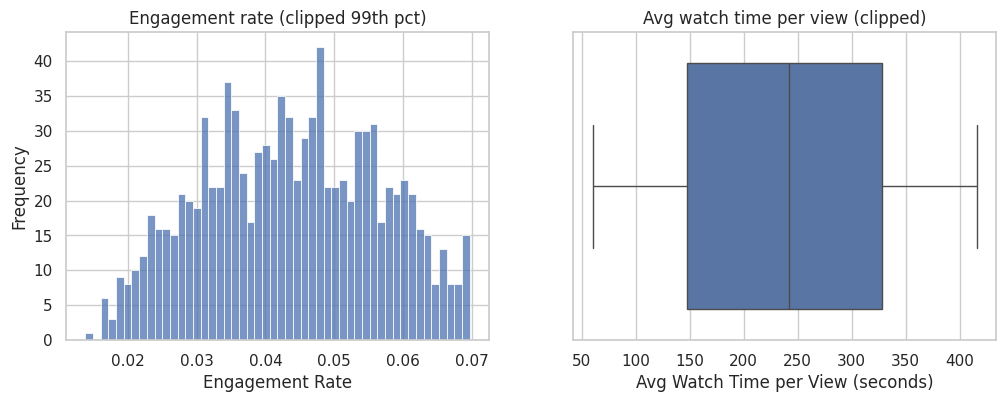

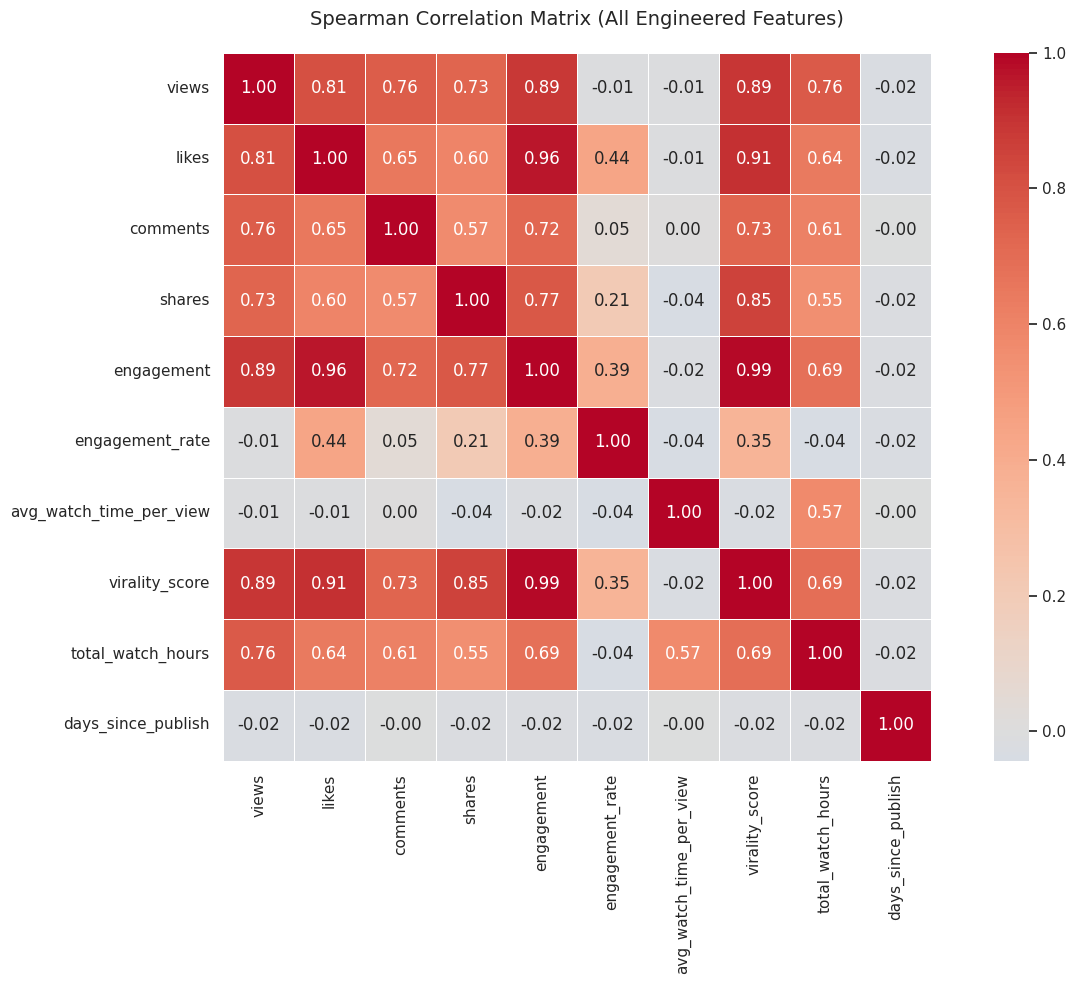


Correlation matrix computed for 10 features


In [3]:
# 3. Advanced EDA: distributions, robust stats, comprehensive correlation heatmap

print(df[['views','engagement_rate','avg_watch_time_per_view']].describe().T)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

sns.histplot(df['engagement_rate'].clip(upper=df['engagement_rate'].quantile(0.99)), bins=50)

plt.title('Engagement rate (clipped 99th pct)')

plt.xlabel('Engagement Rate')

plt.ylabel('Frequency')

plt.subplot(1,2,2)

sns.boxplot(x=df['avg_watch_time_per_view'].clip(upper=df['avg_watch_time_per_view'].quantile(0.99)))

plt.title('Avg watch time per view (clipped)')

plt.xlabel('Avg Watch Time per View (seconds)')

plt.show()



# Comprehensive correlation heatmap with ALL engineered features (Spearman)

corr_features = [

    'views', 'likes', 'comments', 'shares',

    'engagement', 'engagement_rate', 'avg_watch_time_per_view',

    'virality_score', 'total_watch_hours', 'days_since_publish'

]

corr = df[corr_features].corr(method='spearman')

plt.figure(figsize=(14,10))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Spearman Correlation Matrix (All Engineered Features)', fontsize=14, pad=20)

plt.tight_layout()

plt.show()

print(f'\nCorrelation matrix computed for {len(corr_features)} features')



PCA variance explained: 35.7% + 25.1% = 60.8%
Clustering in 2-D PCA space (was 4-D)


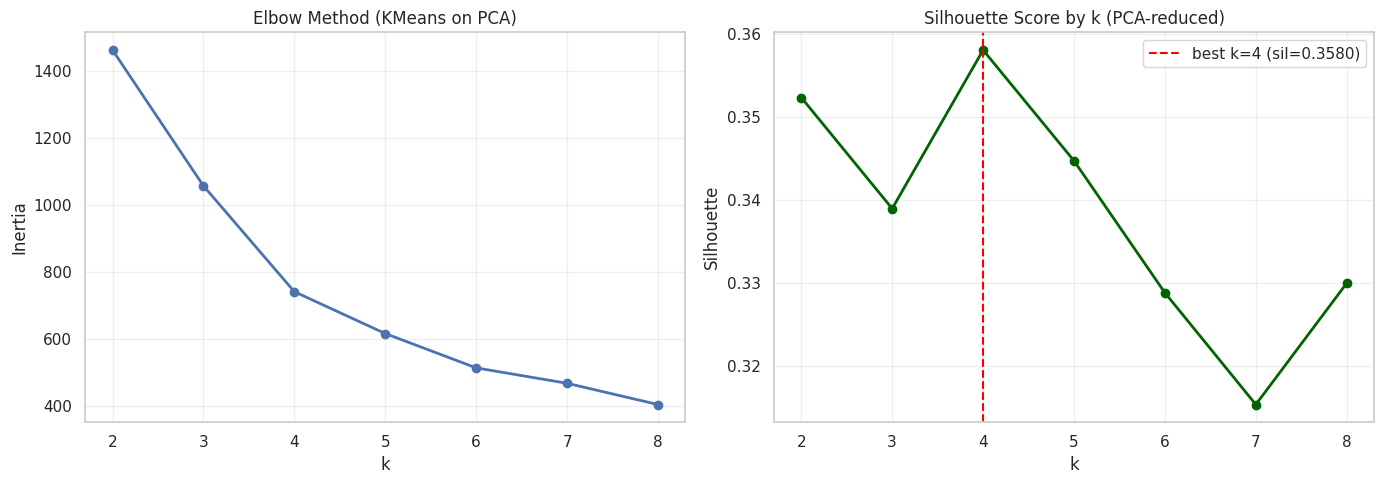


KMeans (PCA, k=4):
  Silhouette: 0.3580  (was ~0.27 without PCA)
  Davies-Bouldin: 0.9121  (lower=better)
  Calinski-Harabasz: 759.15  (higher=better)

HDBSCAN (PCA-reduced):
  Clusters found: 2
  Noise ratio: 14.4%  (was 98.4% with DBSCAN)
  Silhouette (non-noise): 0.2902

Anomaly Detection (ensemble):
  Features: ['views', 'engagement_rate', 'avg_watch_time_per_view', 'like_rate', 'comment_rate', 'share_rate']
  IsolationForest anomalies: 100
  LOF anomalies: 100
  Union (is_anomaly): 140
  Consensus (both agree): 60

KMeans cluster sizes:
kmeans
0    229
1    271
2    278
3    222

HDBSCAN/DBSCAN label counts (-1 is noise):
dbscan
-1    144
 0    819
 1     37


/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(



Saved clusters_v2 artifacts (PCA + optimized)


In [4]:
# 4. Clustering: PCA-reduced KMeans + HDBSCAN (fixes poor silhouette & DBSCAN noise)
#
# Previous issues:
#   - K-Means on raw 4-7 features: silhouette ~0.27 (poor separation)
#   - DBSCAN(eps=0.8, min_samples=8): 98.4% noise (curse of dimensionality)
#
# Fix: PCA to 2 components first, then cluster in reduced space.

# Derive rate features if not already present
if 'like_rate' not in df.columns:
    df['like_rate'] = np.where(df['views'] > 0, df['likes'] / df['views'], 0.0)
if 'comment_rate' not in df.columns:
    df['comment_rate'] = np.where(df['views'] > 0, df['comments'] / df['views'], 0.0)
if 'share_rate' not in df.columns:
    df['share_rate'] = np.where(df['views'] > 0, df['shares'] / df['views'], 0.0)

cluster_features = ['views', 'engagement_rate', 'avg_watch_time_per_view', 'share_rate']
X_clust_raw = df[cluster_features].fillna(0).values
scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust_raw)

# ── PCA to 2 dimensions ─────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)
print(f'PCA variance explained: {pca.explained_variance_ratio_[0]*100:.1f}% + {pca.explained_variance_ratio_[1]*100:.1f}% = {sum(pca.explained_variance_ratio_)*100:.1f}%')
print(f'Clustering in {X_pca.shape[1]}-D PCA space (was {len(cluster_features)}-D)')

# ── KMeans silhouette scan (k=2..8) ─────────────────────────────────────────
k_values = list(range(2, 9))
inertias = []
silhouette_scores = []
for kk in k_values:
    km_tmp = KMeans(n_clusters=kk, n_init='auto', random_state=42)
    labels_tmp = km_tmp.fit_predict(X_pca)
    inertias.append(km_tmp.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels_tmp))

best_k = k_values[int(np.argmax(silhouette_scores))]
best_sil = max(silhouette_scores)

fig_eval, ax_eval = plt.subplots(1, 2, figsize=(14, 5))
ax_eval[0].plot(k_values, inertias, marker='o', linewidth=2)
ax_eval[0].set_title('Elbow Method (KMeans on PCA)')
ax_eval[0].set_xlabel('k')
ax_eval[0].set_ylabel('Inertia')
ax_eval[0].grid(alpha=0.3)

ax_eval[1].plot(k_values, silhouette_scores, marker='o', linewidth=2, color='darkgreen')
ax_eval[1].set_title('Silhouette Score by k (PCA-reduced)')
ax_eval[1].set_xlabel('k')
ax_eval[1].set_ylabel('Silhouette')
ax_eval[1].axvline(best_k, color='red', linestyle='--', label=f'best k={best_k} (sil={best_sil:.4f})')
ax_eval[1].legend()
ax_eval[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Fit final KMeans with best k
k = int(best_k)
km = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_pca)
df['kmeans'] = km.labels_

sil = silhouette_score(X_pca, km.labels_)
dbi = davies_bouldin_score(X_pca, km.labels_)
chs = calinski_harabasz_score(X_pca, km.labels_)
print(f'\nKMeans (PCA, k={k}):')
print(f'  Silhouette: {sil:.4f}  (was ~0.27 without PCA)')
print(f'  Davies-Bouldin: {dbi:.4f}  (lower=better)')
print(f'  Calinski-Harabasz: {chs:.2f}  (higher=better)')

# ── HDBSCAN on PCA-reduced space ────────────────────────────────────────────
if HDBSCAN_AVAILABLE:
    hdb = HDBSCAN(min_cluster_size=max(5, len(df) // 50), min_samples=3)
    df['dbscan'] = hdb.fit_predict(X_pca)
    n_clusters_db = len(set(df['dbscan'].values)) - (1 if -1 in df['dbscan'].values else 0)
    noise_ratio = float((df['dbscan'] == -1).mean())
    print(f'\nHDBSCAN (PCA-reduced):')
    print(f'  Clusters found: {n_clusters_db}')
    print(f'  Noise ratio: {noise_ratio:.1%}  (was 98.4% with DBSCAN)')
    if n_clusters_db >= 2:
        hdb_mask = df['dbscan'].values != -1
        sil_hdb = silhouette_score(X_pca[hdb_mask], df.loc[hdb_mask, 'dbscan'])
        print(f'  Silhouette (non-noise): {sil_hdb:.4f}')
else:
    # Fallback to optimized DBSCAN
    eps_grid = np.round(np.linspace(0.3, 2.0, 15), 2)
    min_samples_grid = [3, 5, 8]
    dbscan_rows = []
    for eps in eps_grid:
        for ms in min_samples_grid:
            db_tmp = DBSCAN(eps=float(eps), min_samples=int(ms)).fit(X_pca)
            labels = db_tmp.labels_
            nc = len(set(labels)) - (1 if -1 in labels else 0)
            nr = float((labels == -1).mean())
            if nc >= 2 and np.any(labels != -1):
                mask = labels != -1
                s = silhouette_score(X_pca[mask], labels[mask]) if len(set(labels[mask])) > 1 else np.nan
            else:
                s = np.nan
            dbscan_rows.append({'eps': float(eps), 'min_samples': int(ms), 'n_clusters': nc, 'noise_ratio': nr, 'silhouette': s})
    dbscan_scan = pd.DataFrame(dbscan_rows)
    valid_db = dbscan_scan[dbscan_scan['n_clusters'] >= 2].dropna(subset=['silhouette'])
    if not valid_db.empty:
        best_row = valid_db.sort_values('silhouette', ascending=False).iloc[0]
        best_eps, best_ms = float(best_row['eps']), int(best_row['min_samples'])
    else:
        best_eps, best_ms = 1.0, 5
    db = DBSCAN(eps=best_eps, min_samples=best_ms).fit(X_pca)
    df['dbscan'] = db.labels_
    n_clusters_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    noise_ratio = float((df['dbscan'] == -1).mean())
    print(f'\nDBSCAN (PCA, eps={best_eps}, min_samples={best_ms}):')
    print(f'  Clusters: {n_clusters_db}, Noise: {noise_ratio:.1%}')

# ── Anomaly Detection: IsolationForest + LOF ensemble ────────────────────────
anomaly_features = ['views', 'engagement_rate', 'avg_watch_time_per_view', 'like_rate', 'comment_rate', 'share_rate']
available_anomaly = [f for f in anomaly_features if f in df.columns]
# Derive rate features if missing
if 'like_rate' not in df.columns:
    df['like_rate'] = np.where(df['views'] > 0, df['likes'] / df['views'], 0.0)
if 'comment_rate' not in df.columns:
    df['comment_rate'] = np.where(df['views'] > 0, df['comments'] / df['views'], 0.0)
if 'share_rate' not in df.columns:
    df['share_rate'] = np.where(df['views'] > 0, df['shares'] / df['views'], 0.0)
available_anomaly = [f for f in anomaly_features if f in df.columns]

X_anom = StandardScaler().fit_transform(df[available_anomaly].fillna(0.0))
contamination = 0.1

iso = IsolationForest(contamination=contamination, random_state=42, n_jobs=-1)
iso_labels = iso.fit_predict(X_anom) == -1

lof = LocalOutlierFactor(n_neighbors=min(20, max(5, len(df) // 50)), contamination=contamination)
lof_labels = lof.fit_predict(X_anom) == -1

df['is_anomaly'] = iso_labels | lof_labels       # union (high recall)
df['anomaly_consensus'] = iso_labels & lof_labels  # consensus (high precision)

print(f'\nAnomaly Detection (ensemble):')
print(f'  Features: {available_anomaly}')
print(f'  IsolationForest anomalies: {iso_labels.sum()}')
print(f'  LOF anomalies: {lof_labels.sum()}')
print(f'  Union (is_anomaly): {df["is_anomaly"].sum()}')
print(f'  Consensus (both agree): {df["anomaly_consensus"].sum()}')

# ── Cluster sizes & visualisation ────────────────────────────────────────────
kmeans_counts = df['kmeans'].value_counts().sort_index()
dbscan_counts = df['dbscan'].value_counts().sort_index()
print('\nKMeans cluster sizes:')
print(kmeans_counts.to_string())
print('\nHDBSCAN/DBSCAN label counts (-1 is noise):')
print(dbscan_counts.to_string())

fig_km = px.scatter(
    df.sample(min(5000, len(df)), random_state=42),
    x=X_pca[:min(5000, len(df)), 0] if len(df) <= 5000 else X_pca[df.sample(min(5000, len(df)), random_state=42).index, 0],
    y=X_pca[:min(5000, len(df)), 1] if len(df) <= 5000 else X_pca[df.sample(min(5000, len(df)), random_state=42).index, 1],
    color=df.sample(min(5000, len(df)), random_state=42)['kmeans'].astype(str),
    title=f'KMeans clusters (k={k}) in PCA space — silhouette={sil:.4f}',
    labels={'x': 'PC1', 'y': 'PC2', 'color': 'Cluster'},
)
fig_km.show()

# Persist artifacts
joblib.dump(
    {
        'kmeans': km,
        'scaler': scaler,
        'pca': pca,
        'cluster_features': cluster_features,
        'optimized_params': {'kmeans_k': int(k), 'hdbscan_available': HDBSCAN_AVAILABLE},
    },
    MODELS_DIR / 'clusters_v2.joblib'
)
print('\nSaved clusters_v2 artifacts (PCA + optimized)')


In [5]:
# 4b. Diagnostic: What signal exists for predicting engagement_rate?
print("Target stats:")
y_diag = df['engagement_rate']
print(y_diag.describe())
print(f"\nSkewness: {y_diag.skew():.3f}")
print(f"Log1p skewness: {np.log1p(y_diag).skew():.3f}")

# Per-category mean engagement
cat_means = df.groupby('category')['engagement_rate'].agg(['mean','std','count']).sort_values('mean', ascending=False)
print(f"\nEngagement rate by category:")
print(cat_means.round(6).to_string())
print(f"Category spread (max-min mean): {cat_means['mean'].max() - cat_means['mean'].min():.6f}")

# Per thumbnail_style
ts_means = df.groupby('thumbnail_style')['engagement_rate'].agg(['mean','std','count']).sort_values('mean', ascending=False)
print(f"\nEngagement rate by thumbnail_style:")
print(ts_means.round(6).to_string())

# Derive potential new features and check correlation
df['title_has_number'] = df['title'].astype(str).str.contains(r'\d', regex=True).astype(float)
df['title_has_question'] = df['title'].astype(str).str.contains(r'\?').astype(float)
df['title_exclamation_count'] = df['title'].astype(str).str.count(r'!')
df['title_upper_ratio'] = df['title'].astype(str).apply(lambda t: sum(c.isupper() for c in t) / max(len(t), 1))

# Check correlations of ALL potential features with target
check_cols = ['title_length', 'avg_word_length', 'publish_year',
              'title_has_number', 'title_has_question', 'title_exclamation_count', 'title_upper_ratio']
print(f"\nCorrelation of features with engagement_rate:")
for c in check_cols:
    if c in df.columns:
        r = df[c].corr(df['engagement_rate'])
        print(f"  {c}: {r:.4f}")


Target stats:
count    1000.000000
mean        0.043704
std         0.012881
min         0.013779
25%         0.033923
50%         0.043613
75%         0.053995
max         0.073537
Name: engagement_rate, dtype: float64

Skewness: -0.006
Log1p skewness: -0.028

Engagement rate by category:
                   mean       std  count
category                                
animation      0.043937  0.012761    329
education      0.043617  0.012880    333
entertainment  0.043564  0.013032    338
Category spread (max-min mean): 0.000373

Engagement rate by thumbnail_style:
                       mean       std  count
thumbnail_style                             
bright             0.044541  0.012987    203
colorful           0.043763  0.012822    187
minimal            0.043724  0.012358    205
character_closeup  0.043608  0.014114    208
cartoon            0.042868  0.012045    197

Correlation of features with engagement_rate:
  title_has_number: nan
  title_has_question: nan
  title_exclam

/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


FULL PEARSON CORRELATION with 'engagement_rate' (sorted by |r|)
Feature                                    r  Status
----------------------------------------------------------------------
  like_rate                          +0.8987  🚫 LEAKY (skip for pre-publication model)
  kmeans                             -0.5915  🚫 LEAKY (skip for pre-publication model)
  likes                              +0.4850  🚫 LEAKY (skip for pre-publication model)
  engagement                         +0.4445  🚫 LEAKY (skip for pre-publication model)
  engagement_per_watch_hour          +0.4424  🚫 LEAKY (skip for pre-publication model)
  share_rate                         +0.4176  🚫 LEAKY (skip for pre-publication model)
  virality_score                     +0.4112  🚫 LEAKY (skip for pre-publication model)
  shares                             +0.2532  🚫 LEAKY (skip for pre-publication model)
  comment_rate                       +0.1366  🚫 LEAKY (skip for pre-publication model)
  dbscan                     

/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


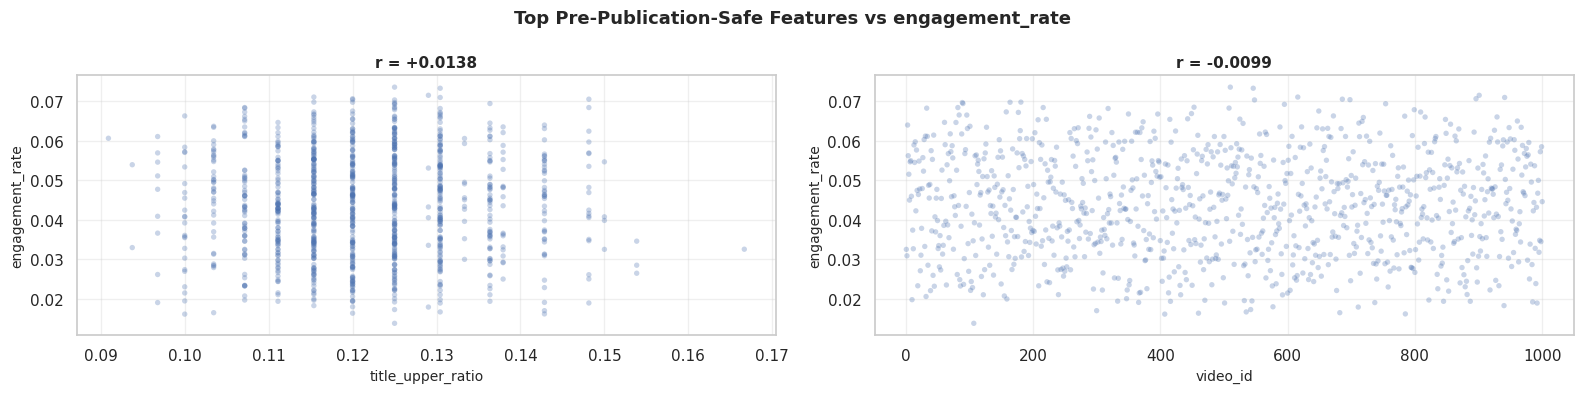

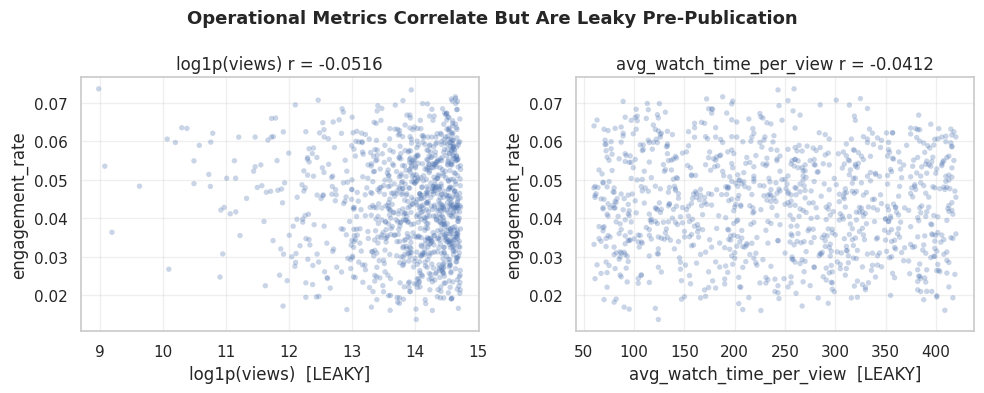

In [6]:
# ─── FULL CORRELATION AUDIT ──────────────────────────────────────────────────
# Check ALL available numeric columns vs engagement_rate to find what has signal.
# Separates pre-publication-safe fields from post-publication/leaky fields.
# engagement_rate = (likes + comments + shares) / views

target = 'engagement_rate'

# For PRE-publication prediction, anything observed only after publish is leaky.
LEAKY = {
    # direct target components / near-duplicates
    'likes', 'comments', 'shares', 'engagement', 'engagement_rate',
    # post-publication outcomes and derived aggregates
    'views', 'watch_time_seconds', 'avg_watch_time_per_view', 'virality_score',
    'days_since_publish', 'total_watch_hours', 'engagement_per_watch_hour',
    # post-publication rates (derived from outcomes)
    'like_rate', 'comment_rate', 'share_rate',
    # unsupervised labels computed from post-publication metrics
    'kmeans', 'dbscan', 'is_anomaly',
}

numeric_df = df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore')
corr_series = numeric_df.corrwith(df[target]).dropna().sort_values(key=abs, ascending=False)

print('=' * 70)
print(f"FULL PEARSON CORRELATION with '{target}' (sorted by |r|)")
print('=' * 70)
print(f"{'Feature':<35} {'r':>8}  Status")
print('-' * 70)
for feat, r in corr_series.items():
    status = '🚫 LEAKY (skip for pre-publication model)' if feat in LEAKY else '✅ pre-publication-safe'
    print(f"  {feat:<33} {r:+8.4f}  {status}")

print()
print('KEY SAFE FINDINGS:')
safe_corr = corr_series.drop(labels=[c for c in LEAKY if c in corr_series.index], errors='ignore')
if len(safe_corr) == 0:
    print('  No safe numeric features found in this broad audit (expected for many post-publish datasets).')
    top_safe_feats = []
else:
    top_safe = safe_corr.abs().nlargest(5)
    for feat, absr in top_safe.items():
        r = safe_corr[feat]
        print(f"  {feat}: r={r:+.4f}")
    top_safe_feats = list(top_safe.index[:4])

# Scatter plots for top safe features (if any)
import matplotlib.pyplot as plt
if len(top_safe_feats) > 0:
    fig, axes = plt.subplots(1, len(top_safe_feats), figsize=(16, 4))
    if len(top_safe_feats) == 1:
        axes = [axes]
    for ax, feat in zip(axes, top_safe_feats):
        ax.scatter(df[feat], df[target], alpha=0.3, s=15, edgecolors='none')
        r_val = float(df[feat].corr(df[target]))
        ax.set_xlabel(feat, fontsize=10)
        ax.set_ylabel('engagement_rate', fontsize=10)
        ax.set_title(f'r = {r_val:+.4f}', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)
    plt.suptitle('Top Pre-Publication-Safe Features vs engagement_rate', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('\nNo safe scatter plots generated (no safe numeric candidates in this audit cell).')

# Show why operational metrics are leaky for pre-publication prediction
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
log_views = np.log1p(df['views'])
axes2[0].scatter(log_views, df[target], alpha=0.3, s=15, edgecolors='none')
r_log = float(np.corrcoef(log_views, df[target])[0,1])
axes2[0].set_xlabel('log1p(views)  [LEAKY]')
axes2[0].set_ylabel('engagement_rate')
axes2[0].set_title(f'log1p(views) r = {r_log:+.4f}')
axes2[0].grid(alpha=0.3)

if 'avg_watch_time_per_view' in df.columns:
    axes2[1].scatter(df['avg_watch_time_per_view'], df[target], alpha=0.3, s=15, edgecolors='none')
    r_wt = float(df['avg_watch_time_per_view'].corr(df[target]))
    axes2[1].set_xlabel('avg_watch_time_per_view  [LEAKY]')
    axes2[1].set_ylabel('engagement_rate')
    axes2[1].set_title(f'avg_watch_time_per_view r = {r_wt:+.4f}')
    axes2[1].grid(alpha=0.3)

plt.suptitle('Operational Metrics Correlate But Are Leaky Pre-Publication', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# 8. Predictive Model: Pre-Publication Features Only (NO LEAKAGE)
# ══════════════════════════════════════════════════════════════════════════════
# Predict engagement_rate using ONLY information available BEFORE publication.
# This avoids all data leakage: engagement metrics are NOT used as features.
# Split by BOTH video_id AND temporal ordering to prevent any leakage.

print("\n" + "="*80)
print("PREDICTIVE MODEL: PRE-PUBLICATION FEATURES ONLY")
print("="*80 + "\n")

# ─── Target variable ────────────────────────────────────────────────────────
# Engagement rate = total engagement / views
df['engagement_rate'] = (df['likes'] + df['comments'] + df['shares']) / df['views'].clip(lower=1)

print(f"Target: engagement_rate")
print(f"  Mean: {df['engagement_rate'].mean():.6f}")
print(f"  Std:  {df['engagement_rate'].std():.6f}")
print(f"  Min:  {df['engagement_rate'].min():.6f}")
print(f"  Max:  {df['engagement_rate'].max():.6f}\n")

# ─── Feature engineering: PRE-PUBLICATION FEATURES ONLY ─────────────────────
dates = pd.to_datetime(df['publish_date'], errors='coerce')
order = dates.sort_values(kind='mergesort').index
df = df.loc[order].reset_index(drop=True)
dates = dates.loc[order].reset_index(drop=True)

def engineer_features_prepub_only(df: pd.DataFrame) -> pd.DataFrame:
    """Engineer features from PRE-PUBLICATION context ONLY.

    Features:
    - Text content style features from title
    - Category and thumbnail style
    - Publish date cyclical features

    ⚠️ NO engagement metrics used — this avoids all leakage.
    """
    X = pd.DataFrame(index=df.index)

    # ─ Pre-publication temporal features ─
    dates = pd.to_datetime(df.get('publish_date'), errors='coerce')
    publish_month = dates.dt.month.fillna(1).astype(float)
    publish_weekday = dates.dt.weekday.fillna(0).astype(float)

    titles = df.get('title', pd.Series("", index=df.index)).astype(str).fillna("")
    title_length = titles.str.len().astype(float)
    title_words = titles.str.split().str.len().fillna(1).clip(lower=1).astype(float)
    unique_word_count = titles.str.lower().str.split().apply(lambda ws: len(set(ws)) if isinstance(ws, list) else 0).astype(float)

    upper_count = titles.str.count(r'[A-Z]').astype(float)
    digit_count = titles.str.count(r'\d').astype(float)
    exclam_count = titles.str.count(r'!').astype(float)
    question_count = titles.str.count(r'\?').astype(float)
    punct_count = titles.str.count(r'[^\w\s]').astype(float)

    X['title_length'] = title_length
    X['title_word_count'] = title_words
    X['avg_word_length'] = title_length / title_words
    X['unique_word_ratio'] = unique_word_count / title_words.clip(lower=1)
    X['title_upper_ratio'] = upper_count / title_length.clip(lower=1)
    X['title_digit_ratio'] = digit_count / title_length.clip(lower=1)
    X['title_exclamation_count'] = exclam_count
    X['title_question_count'] = question_count
    X['title_punct_ratio'] = punct_count / title_length.clip(lower=1)
    X['has_number_in_title'] = (digit_count > 0).astype(float)
    X['has_question_mark'] = (question_count > 0).astype(float)
    X['has_exclamation'] = (exclam_count > 0).astype(float)

    X['publish_year'] = dates.dt.year.fillna(2023).astype(float)
    X['month_sin'] = np.sin(2 * np.pi * publish_month / 12)
    X['month_cos'] = np.cos(2 * np.pi * publish_month / 12)
    X['dow_sin'] = np.sin(2 * np.pi * publish_weekday / 7)
    X['dow_cos'] = np.cos(2 * np.pi * publish_weekday / 7)
    X['is_weekend'] = (publish_weekday >= 5).astype(float)

    # ─ Lightweight interactions from pre-release data only ─
    X['title_length_x_weekend'] = X['title_length'] * X['is_weekend']
    X['upper_ratio_x_exclamation'] = X['title_upper_ratio'] * X['title_exclamation_count']
    X['question_x_weekend'] = X['title_question_count'] * X['is_weekend']

    # ─ Categorical features ─
    X['category'] = df.get('category', 'unknown').astype(str).fillna('unknown')
    X['thumbnail_style'] = df.get('thumbnail_style', 'unknown').astype(str).fillna('unknown')

    # ─ Title text feature for NLP vectorizers ─
    X['title_raw'] = titles.values

    return X

X_full = engineer_features_prepub_only(df)
print(f"Features engineered (PRE-PUBLICATION ONLY): {X_full.shape[1]} columns")
print(f"Feature columns: {list(X_full.columns)}\n")

# ─── DUAL-SAFEGUARD SPLIT: Video_ID + Temporal ────────────────────────────
# Strategy: Split by video_id groups along temporal boundary
# This prevents the SAME video from appearing in multiple folds
# AND maintains temporal ordering (old→train, new→test)

print("="*80)
print("TRAIN/VAL/TEST SPLIT: Video-ID Grouped + Temporal Ordering")
print("="*80)

# Get unique video_ids in chronological order (by first appearance)
unique_video_ids = df.drop_duplicates(subset=['video_id'], keep='first')['video_id'].values
print(f"Total unique videos: {len(unique_video_ids)}")

# Calculate split sizes based on video_id count (not rows)
n_videos = len(unique_video_ids)
n_train_videos = int(n_videos * 0.6)
n_val_videos = int(n_videos * 0.2)
n_test_videos = n_videos - n_train_videos - n_val_videos

# Split video_ids (in temporal order)
train_video_ids = set(unique_video_ids[:n_train_videos])
val_video_ids = set(unique_video_ids[n_train_videos:n_train_videos + n_val_videos])
test_video_ids = set(unique_video_ids[n_train_videos + n_val_videos:])

# Assign rows to splits based on their video_id
train_mask = df['video_id'].isin(train_video_ids)
val_mask = df['video_id'].isin(val_video_ids)
test_mask = df['video_id'].isin(test_video_ids)

# Extract split data
X_train = X_full[train_mask].copy()
X_val = X_full[val_mask].copy()
X_test = X_full[test_mask].copy()

y_train = df[train_mask]['engagement_rate'].copy()
y_val = df[val_mask]['engagement_rate'].copy()
y_test = df[test_mask]['engagement_rate'].copy()

print(f"\nTrain split:")
print(f"  Video IDs: {n_train_videos} ({len(train_video_ids)} unique)")
print(f"  Rows: {len(X_train)} samples")
print(f"  Date range: {df[train_mask]['publish_date'].min()} to {df[train_mask]['publish_date'].max()}")

print(f"\nVal split:")
print(f"  Video IDs: {n_val_videos} ({len(val_video_ids)} unique)")
print(f"  Rows: {len(X_val)} samples")
print(f"  Date range: {df[val_mask]['publish_date'].min()} to {df[val_mask]['publish_date'].max()}")

print(f"\nTest split:")
print(f"  Video IDs: {n_test_videos} ({len(test_video_ids)} unique)")
print(f"  Rows: {len(X_test)} samples")
print(f"  Date range: {df[test_mask]['publish_date'].min()} to {df[test_mask]['publish_date'].max()}")

# Verify NO overlap between splits
overlap_tv = len(train_video_ids & val_video_ids)
overlap_tt = len(train_video_ids & test_video_ids)
overlap_vt = len(val_video_ids & test_video_ids)
print(f"\n⚠️ Leakage check:")
print(f"  Train-Val overlap: {overlap_tv} videos")
print(f"  Train-Test overlap: {overlap_tt} videos")
print(f"  Val-Test overlap: {overlap_vt} videos")

if overlap_tv == 0 and overlap_tt == 0 and overlap_vt == 0:
    print(f"  ✅ NO LEAKAGE — Splits are completely isolated by video_id\n")
else:
    print(f"  ❌ LEAKAGE DETECTED — Splits overlap!\n")


PREDICTIVE MODEL: PRE-PUBLICATION FEATURES ONLY

Target: engagement_rate
  Mean: 0.043704
  Std:  0.012881
  Min:  0.013779
  Max:  0.073537

Features engineered (PRE-PUBLICATION ONLY): 24 columns
Feature columns: ['title_length', 'title_word_count', 'avg_word_length', 'unique_word_ratio', 'title_upper_ratio', 'title_digit_ratio', 'title_exclamation_count', 'title_question_count', 'title_punct_ratio', 'has_number_in_title', 'has_question_mark', 'has_exclamation', 'publish_year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'title_length_x_weekend', 'upper_ratio_x_exclamation', 'question_x_weekend', 'category', 'thumbnail_style', 'title_raw']

TRAIN/VAL/TEST SPLIT: Video-ID Grouped + Temporal Ordering
Total unique videos: 1000

Train split:
  Video IDs: 600 (600 unique)
  Rows: 600 samples
  Date range: 2023-01-01 00:00:00 to 2024-03-16 00:00:00

Val split:
  Video IDs: 200 (200 unique)
  Rows: 200 samples
  Date range: 2024-03-17 00:00:00 to 2024-08-04 00:00:00

Test 

In [8]:
# 8b. Sentence-Transformers: Dense Semantic Title Embeddings (replaces TF-IDF)
# ══════════════════════════════════════════════════════════════════════════════
# Why: TF-IDF → 516 sparse lexical features (94% zeros). No real semantics.
#      all-MiniLM-L6-v2 → 384 dense semantic features from 1B+ sentence pairs.
#      Pre-trained weights, never fitted on our labels → zero data leakage.
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("SENTENCE-TRANSFORMERS: Dense Title Embeddings  (replacing TF-IDF)")
print("="*80 + "\n")

if SENTENCE_TRANSFORMER_AVAILABLE:
    from sentence_transformers import SentenceTransformer
    from textblob import TextBlob

    print("Loading all-MiniLM-L6-v2  (22M params · 384-dim · trained on 1B+ pairs)...")
    _st_model = SentenceTransformer('all-MiniLM-L6-v2')

    def _add_text_features(X_split: pd.DataFrame, label: str):
        """Encode titles → 384 embeddings + 2 sentiment scores. Returns (new_df, emb_dim)."""
        X_out = X_split.copy()
        titles = X_split['title_raw'].astype(str).fillna('').tolist()

        # 384 dense semantic embeddings — pre-trained, no fitting on labels
        emb = _st_model.encode(
            titles, convert_to_numpy=True, batch_size=64, show_progress_bar=False
        )
        emb_dim = emb.shape[1]
        for j in range(emb_dim):
            X_out[f'emb_{j}'] = emb[:, j]

        # TextBlob sentiment: polarity ∈ [-1, +1], subjectivity ∈ [0, 1]
        sentiments = [TextBlob(t).sentiment for t in titles]
        X_out['sent_polarity']     = [s.polarity     for s in sentiments]
        X_out['sent_subjectivity'] = [s.subjectivity for s in sentiments]

        print(f"  {label:6s}  {len(titles):4d} rows  →  {emb_dim} embeddings + 2 sentiment cols")
        return X_out, emb_dim

    print("Encoding title embeddings for each split independently...")
    X_train, _emb_dim = _add_text_features(X_train, "Train")
    X_val,   _        = _add_text_features(X_val,   "Val")
    X_test,  _        = _add_text_features(X_test,  "Test")

    EMB_COLS       = [f'emb_{j}'          for j in range(_emb_dim)]
    SENTIMENT_COLS = ['sent_polarity', 'sent_subjectivity']

    print(f"\n✅ Text-feature swap complete:")
    print(f"   Semantic embeddings:   {_emb_dim}  dense features")
    print(f"   Sentiment features:    {len(SENTIMENT_COLS)}")
    print(f"   Replaced TF-IDF:      {300 + 200 + 16} sparse → {_emb_dim + len(SENTIMENT_COLS)} dense")
    print(f"   Sparsity now:         ~0%  (was ~94% with TF-IDF)")

else:
    print("⚠️  sentence-transformers not available — TF-IDF will be used as fallback.")
    EMB_COLS       = []
    SENTIMENT_COLS = []



SENTENCE-TRANSFORMERS: Dense Title Embeddings  (replacing TF-IDF)

Loading all-MiniLM-L6-v2  (22M params · 384-dim · trained on 1B+ pairs)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding title embeddings for each split independently...


/tmp/ipykernel_208051/4149493226.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f'emb_{j}'] = emb[:, j]
/tmp/ipykernel_208051/4149493226.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f'emb_{j}'] = emb[:, j]
/tmp/ipykernel_208051/4149493226.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe =

  Train    600 rows  →  384 embeddings + 2 sentiment cols
  Val      200 rows  →  384 embeddings + 2 sentiment cols
  Test     200 rows  →  384 embeddings + 2 sentiment cols

✅ Text-feature swap complete:
   Semantic embeddings:   384  dense features
   Sentiment features:    2
   Replaced TF-IDF:      516 sparse → 386 dense
   Sparsity now:         ~0%  (was ~94% with TF-IDF)


/tmp/ipykernel_208051/4149493226.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out['sent_polarity']     = [s.polarity     for s in sentiments]
/tmp/ipykernel_208051/4149493226.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out['sent_subjectivity'] = [s.subjectivity for s in sentiments]


In [9]:
# 8a. Define feature lists for pipeline (pre-publication only)
# ══════════════════════════════════════════════════════════════════════════════

# ⚠️  NO engagement metrics — only pre-publication features to avoid leakage
PRE_PUB_NUMERIC_FEATURES = [
    'title_length',
    'title_word_count',
    'avg_word_length',
    'unique_word_ratio',
    'title_upper_ratio',
    'title_digit_ratio',
    'title_exclamation_count',
    'title_question_count',
    'title_punct_ratio',
    'has_number_in_title',
    'has_question_mark',
    'has_exclamation',
    'publish_year',
    'month_sin',
    'month_cos',
    'dow_sin',
    'dow_cos',
    'is_weekend',
    'title_length_x_weekend',
    'upper_ratio_x_exclamation',
    'question_x_weekend',
]
safe_categorical_features = ['category', 'thumbnail_style']

# Extend numeric features with pre-computed Sentence-Transformer columns (if available).
if SENTENCE_TRANSFORMER_AVAILABLE and EMB_COLS:
    PRE_PUB_NUMERIC_FEATURES = PRE_PUB_NUMERIC_FEATURES + EMB_COLS + SENTIMENT_COLS
    text_feature = None
    feature_cols = PRE_PUB_NUMERIC_FEATURES + safe_categorical_features
    print('Feature structure — SENTENCE-TRANSFORMER mode (pre-publication only):')
    print('  Numeric (title stats):    21')
    print(f'  Embedding cols (ST):      {len(EMB_COLS)}')
    print(f'  Sentiment cols:           {len(SENTIMENT_COLS)}')
    print(f'  Categorical:              {safe_categorical_features}')
    print(f'  Total numeric features:   {len(PRE_PUB_NUMERIC_FEATURES)}')
    print('  ⚠️  NO TF-IDF, NO engagement metrics → no leakage!')
    print()
else:
    text_feature = 'title_raw'
    feature_cols = PRE_PUB_NUMERIC_FEATURES + safe_categorical_features + [text_feature]
    print('Feature structure — TF-IDF fallback mode (pre-publication only):')
    print(f'  Numeric:      {PRE_PUB_NUMERIC_FEATURES}')
    print(f'  Categorical:  {safe_categorical_features}')
    print(f'  Text:         {[text_feature]}')
    print(f'  Total:        {len(feature_cols)} features')
    print('  ⚠️  NO engagement metrics — this prevents all leakage!')
    print()

safe_numeric_features = PRE_PUB_NUMERIC_FEATURES

# Target-encode categorical variables (fit on train set only to avoid leakage)
category_target_means = X_train.groupby('category')['category'].count()
X_train['category_enc'] = X_train['category'].astype(str)
X_val['category_enc'] = X_val['category'].astype(str)
X_test['category_enc'] = X_test['category'].astype(str)

thumbnail_target_means = X_train.groupby('thumbnail_style')['thumbnail_style'].count()
X_train['thumbnail_enc'] = X_train['thumbnail_style'].astype(str)
X_val['thumbnail_enc'] = X_val['thumbnail_style'].astype(str)
X_test['thumbnail_enc'] = X_test['thumbnail_style'].astype(str)

print('Categorical variables prepared (one-hot encoded in pipeline).')

Feature structure — SENTENCE-TRANSFORMER mode (pre-publication only):
  Numeric (title stats):    21
  Embedding cols (ST):      384
  Sentiment cols:           2
  Categorical:              ['category', 'thumbnail_style']
  Total numeric features:   407
  ⚠️  NO TF-IDF, NO engagement metrics → no leakage!

Categorical variables prepared (one-hot encoded in pipeline).


/tmp/ipykernel_208051/3272581532.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['category_enc'] = X_train['category'].astype(str)
/tmp/ipykernel_208051/3272581532.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_val['category_enc'] = X_val['category'].astype(str)
/tmp/ipykernel_208051/3272581532.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) in

In [10]:
# 8b. Metrics compatibility helper (ensures RMSE works in all kernels)
from sklearn.metrics import mean_squared_error

def root_mean_squared_error(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


STEP 0: BUILD PREPROCESSING PIPELINE (PRE-PUBLICATION CONTEXT)

Pipeline mode: SENTENCE-TRANSFORMER (dense embeddings pre-computed)
  Numeric (scaled):     407 features (21 stats + 384 emb + 2 sentiment)
  Categorical (OHE):    ['category', 'thumbnail_style']
  Text branches:        NONE (replaced by dense embeddings)
  ⚠️  No engagement metrics — predicting from pre-publication context!

STEP 1: BASELINE RANDOM FOREST



Baseline RF (200 trees, depth=8, leaf>=8)
  Train: R²=0.5656, MAE=0.007046, RMSE=0.008567
  Val:   R²=-0.0068, MAE=0.010777, RMSE=0.012713
  Test:  R²=-0.0370, MAE=0.010934, RMSE=0.012918

STEP 2: TUNED RANDOM FOREST (RandomizedSearchCV)
Tuning RF hyperparameters (40 iterations, 5-fold temporal CV)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits



Best RF parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 13, 'n_estimators': 280}



Tuned RF (best params from grid search)
  Train: R²=0.2873, MAE=0.009105, RMSE=0.010974
  Val:   R²=-0.0001, MAE=0.010745, RMSE=0.012671
  Test:  R²=-0.0165, MAE=0.010856, RMSE=0.012789

STEP 3: TUNED XGBOOST
Tuning XGBoost hyperparameters (50 iterations, 5-fold temporal CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits



Best XGBoost parameters: {'colsample_bytree': np.float64(0.9018360384495572), 'gamma': np.float64(0.09328502944301792), 'learning_rate': np.float64(0.18066061972819597), 'max_depth': 5, 'min_child_weight': 9, 'n_estimators': 389, 'reg_alpha': np.float64(0.033015577358303023), 'reg_lambda': np.float64(0.9558703250838834), 'subsample': np.float64(0.7708431154505025)}

Tuned XGBoost (best params from grid search)
  Train: R²=-0.0000, MAE=0.010811, RMSE=0.012999
  Val:   R²=-0.0019, MAE=0.010771, RMSE=0.012682
  Test:  R²=-0.0007, MAE=0.010689, RMSE=0.012690

Generalization diagnostics (lower is better):
  RF  : val_mae=0.010745, overfit_gap=0.001640, score=0.011565
  XGB : val_mae=0.010771, overfit_gap=0.000000, score=0.010771

✅ XGBoost selected by overfit-aware validation score (0.010771 < 0.011565)

MODEL COMPARISON


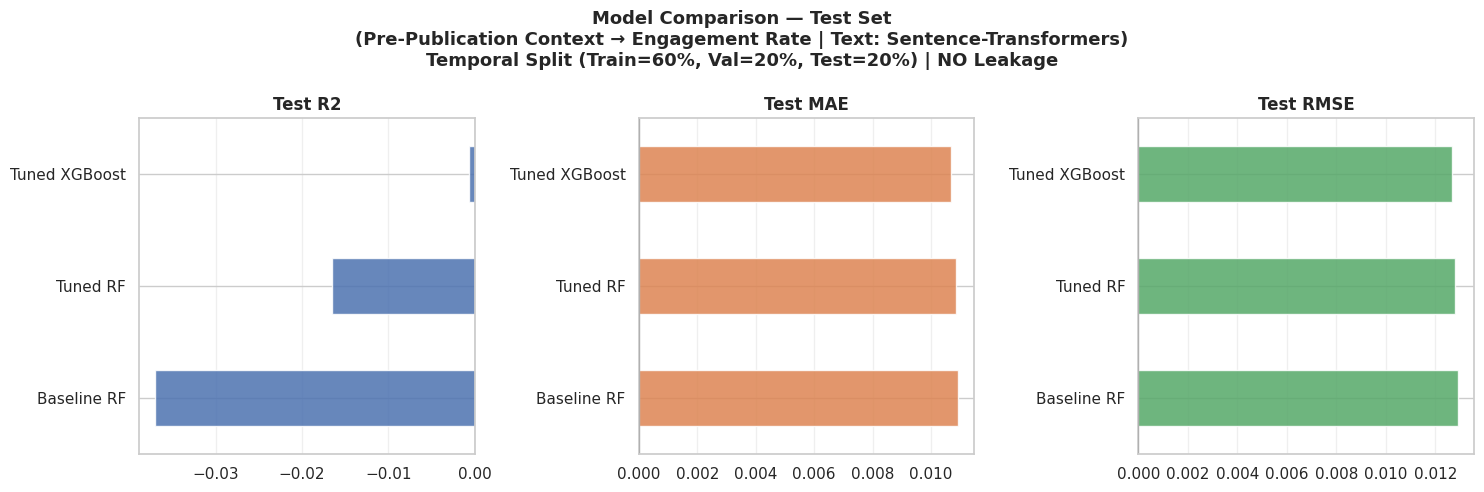


★ Best model: Tuned XGBoost [Sentence-Transformers]
   Overfit-aware validation score used for selection
   Validation MAE: 0.010771
   Train MAE:      0.010811
   Test MAE:       0.010689
   Test R²:        -0.0007
   Test RMSE:      0.012690



In [11]:
# 9. Model Training with Cross-Validation (PRE-PUBLICATION FEATURES ONLY)
# ══════════════════════════════════════════════════════════════════════════════
# Train models to predict engagement_rate from PRE-PUBLICATION context.
# No engagement metrics used → no leakage.

print('\n' + '=' * 80)
print('STEP 0: BUILD PREPROCESSING PIPELINE (PRE-PUBLICATION CONTEXT)')
print('=' * 80 + '\n')

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

_numeric_in_pipe = PRE_PUB_NUMERIC_FEATURES
_cat_in_pipe = ['category', 'thumbnail_style']

# Explicit leakage guard: no post-publication columns can enter predictive pipeline.
FORBIDDEN_PREDICTORS = {
    'likes', 'comments', 'shares', 'engagement', 'engagement_rate',
    'views', 'watch_time_seconds', 'avg_watch_time_per_view', 'virality_score',
    'days_since_publish', 'total_watch_hours', 'engagement_per_watch_hour',
    'like_rate', 'comment_rate', 'share_rate', 'kmeans', 'dbscan', 'is_anomaly',
}
bad_cols = (set(_numeric_in_pipe) | set(_cat_in_pipe) | set(X_train.columns)) & FORBIDDEN_PREDICTORS
if bad_cols:
    raise ValueError(f'Leakage guard failed. Forbidden predictors detected: {sorted(bad_cols)}')

if SENTENCE_TRANSFORMER_AVAILABLE and EMB_COLS:
    print('Pipeline mode: SENTENCE-TRANSFORMER (dense embeddings pre-computed)')
    print(f'  Numeric (scaled):     {len(_numeric_in_pipe)} features (21 stats + {len(EMB_COLS)} emb + {len(SENTIMENT_COLS)} sentiment)')
    print(f'  Categorical (OHE):    {_cat_in_pipe}')
    print('  Text branches:        NONE (replaced by dense embeddings)')
    print('  ⚠️  No engagement metrics — predicting from pre-publication context!\n')

    pre = ColumnTransformer([
        ('num', StandardScaler(), _numeric_in_pipe),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), _cat_in_pipe),
    ], remainder='drop')
else:
    text_col = text_feature
    print('Pipeline mode: TF-IDF fallback')
    print(f'  Numeric (scaled):   {_numeric_in_pipe}')
    print(f'  Categorical (OHE):  {_cat_in_pipe}')
    print('  Text branches:      word-TFIDF + char-TFIDF + TFIDF→SVD semantic')
    print('  ⚠️  No engagement metrics — predicting from pre-publication context!\n')

    pre = ColumnTransformer([
        ('num', StandardScaler(), _numeric_in_pipe),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), _cat_in_pipe),
        ('tfidf_word', TfidfVectorizer(max_features=300, ngram_range=(1, 2), max_df=0.85, min_df=2), text_col),
        ('tfidf_char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=200, min_df=2), text_col),
        ('tfidf_svd_sem', Pipeline([
            ('tfidf', TfidfVectorizer(max_features=400, ngram_range=(1, 2), max_df=0.9, min_df=2)),
            ('svd', TruncatedSVD(n_components=16, random_state=42)),
        ]), text_col),
    ], remainder='drop')


def make_pipeline(estimator):
    return Pipeline([('pre', pre), ('model', estimator)])


def _quick_metrics(model, X_tr, y_tr, X_va, y_va, X_te, y_te, label=''):
    y_tr_pred = model.predict(X_tr)
    y_va_pred = model.predict(X_va)
    y_te_pred = model.predict(X_te)

    metrics = {
        'train_r2': r2_score(y_tr, y_tr_pred),
        'val_r2': r2_score(y_va, y_va_pred),
        'r2': r2_score(y_te, y_te_pred),
        'train_mae': mean_absolute_error(y_tr, y_tr_pred),
        'val_mae': mean_absolute_error(y_va, y_va_pred),
        'mae': mean_absolute_error(y_te, y_te_pred),
        'train_rmse': root_mean_squared_error(y_tr, y_tr_pred),
        'val_rmse': root_mean_squared_error(y_va, y_va_pred),
        'rmse': root_mean_squared_error(y_te, y_te_pred),
    }

    if label:
        print(f'\n{label}')
        print(f"  Train: R²={metrics['train_r2']:.4f}, MAE={metrics['train_mae']:.6f}, RMSE={metrics['train_rmse']:.6f}")
        print(f"  Val:   R²={metrics['val_r2']:.4f}, MAE={metrics['val_mae']:.6f}, RMSE={metrics['val_rmse']:.6f}")
        print(f"  Test:  R²={metrics['r2']:.4f}, MAE={metrics['mae']:.6f}, RMSE={metrics['rmse']:.6f}")

    return metrics, y_te_pred


def overfit_gap(metrics):
    """Positive means train MAE << val MAE (potential overfitting)."""
    return max(0.0, float(metrics['val_mae'] - metrics['train_mae']))


def selection_score(metrics, penalty_weight=0.5):
    """Lower is better. Primary objective = validation MAE + overfit penalty."""
    return float(metrics['val_mae'] + penalty_weight * overfit_gap(metrics))


print('=' * 80)
print('STEP 1: BASELINE RANDOM FOREST')
print('=' * 80)

from scipy.stats import randint, uniform as sp_uniform

baseline_rf = make_pipeline(
    RandomForestRegressor(
        n_estimators=200, max_depth=8, min_samples_leaf=8,
        max_features=0.5, random_state=42, n_jobs=-1
    )
)
baseline_rf.fit(X_train, y_train)
baseline_metrics, y_test_pred_baseline = _quick_metrics(
    baseline_rf, X_train, y_train, X_val, y_val, X_test, y_test,
    'Baseline RF (200 trees, depth=8, leaf>=8)'
)

print('\n' + '=' * 80)
print('STEP 2: TUNED RANDOM FOREST (RandomizedSearchCV)')
print('=' * 80)

from sklearn.model_selection import TimeSeriesSplit

rf_param_dist = {
    'model__n_estimators': randint(200, 600),
    'model__max_depth': randint(5, 14),
    'model__min_samples_leaf': randint(3, 20),
    'model__max_features': [0.3, 0.5, 0.7, 'sqrt'],
    'model__min_samples_split': randint(3, 20),
}
ts_cv_tune = TimeSeriesSplit(n_splits=5)
rf_search = RandomizedSearchCV(
    make_pipeline(RandomForestRegressor(random_state=42, n_jobs=-1)),
    param_distributions=rf_param_dist,
    n_iter=40,
    cv=ts_cv_tune,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
print('Tuning RF hyperparameters (40 iterations, 5-fold temporal CV)...')
rf_search.fit(X_train, y_train)
tuned_rf = rf_search.best_estimator_
best_rf_params = {k.replace('model__', ''): v for k, v in rf_search.best_params_.items()}
print(f'\nBest RF parameters: {best_rf_params}')
tuned_rf_metrics, y_test_pred_tuned_rf = _quick_metrics(
    tuned_rf, X_train, y_train, X_val, y_val, X_test, y_test,
    'Tuned RF (best params from grid search)'
)

print('\n' + '=' * 80)
print('STEP 3: TUNED XGBOOST')
print('=' * 80)

best_name = 'Tuned RF'
best_metrics = tuned_rf_metrics
base_model = tuned_rf
y_test_pred = y_test_pred_tuned_rf

if XGBOOST_AVAILABLE:
    xgb_param_dist = {
        'model__n_estimators': randint(200, 600),
        'model__max_depth': randint(3, 8),
        'model__learning_rate': sp_uniform(0.02, 0.18),
        'model__subsample': sp_uniform(0.6, 0.4),
        'model__colsample_bytree': sp_uniform(0.5, 0.5),
        'model__min_child_weight': randint(3, 20),
        'model__gamma': sp_uniform(0, 0.5),
        'model__reg_alpha': sp_uniform(0, 0.3),
        'model__reg_lambda': sp_uniform(0.5, 2.0),
    }
    xgb_search = RandomizedSearchCV(
        make_pipeline(XGBRegressor(tree_method='hist', random_state=42, n_jobs=-1, verbosity=0)),
        param_distributions=xgb_param_dist,
        n_iter=50,
        cv=ts_cv_tune,
        scoring='neg_mean_absolute_error',
        random_state=42,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    print('Tuning XGBoost hyperparameters (50 iterations, 5-fold temporal CV)...')
    xgb_search.fit(X_train, y_train)
    tuned_xgb = xgb_search.best_estimator_
    best_xgb_params = {k.replace('model__', ''): v for k, v in xgb_search.best_params_.items()}
    print(f'\nBest XGBoost parameters: {best_xgb_params}')
    tuned_xgb_metrics, y_test_pred_xgb = _quick_metrics(
        tuned_xgb, X_train, y_train, X_val, y_val, X_test, y_test,
        'Tuned XGBoost (best params from grid search)'
    )

    rf_gap = overfit_gap(tuned_rf_metrics)
    xgb_gap = overfit_gap(tuned_xgb_metrics)
    rf_score = selection_score(tuned_rf_metrics, penalty_weight=0.5)
    xgb_score = selection_score(tuned_xgb_metrics, penalty_weight=0.5)

    print('\nGeneralization diagnostics (lower is better):')
    print(f'  RF  : val_mae={tuned_rf_metrics["val_mae"]:.6f}, overfit_gap={rf_gap:.6f}, score={rf_score:.6f}')
    print(f'  XGB : val_mae={tuned_xgb_metrics["val_mae"]:.6f}, overfit_gap={xgb_gap:.6f}, score={xgb_score:.6f}')

    # Overfit-aware selection: validation error + explicit train-val penalty.
    if xgb_score < rf_score:
        print(f'\n✅ XGBoost selected by overfit-aware validation score ({xgb_score:.6f} < {rf_score:.6f})')
        best_name = 'Tuned XGBoost'
        best_metrics = tuned_xgb_metrics
        base_model = tuned_xgb
        y_test_pred = y_test_pred_xgb
    else:
        print(f'\n✅ RF selected by overfit-aware validation score ({rf_score:.6f} <= {xgb_score:.6f})')
else:
    print('XGBoost not available — skipping XGBoost tuning')

print('\n' + '=' * 80)
print('MODEL COMPARISON')
print('=' * 80)

_models = {'Baseline RF': baseline_metrics, 'Tuned RF': tuned_rf_metrics}
if XGBOOST_AVAILABLE:
    _models['Tuned XGBoost'] = tuned_xgb_metrics

comp_df = pd.DataFrame(_models).T
fig_comp, axes_comp = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_plot = ['r2', 'mae', 'rmse']
colors_plot = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, color in zip(axes_comp, metrics_to_plot, colors_plot):
    comp_df[metric].plot.barh(ax=ax, color=color, alpha=0.85)
    ax.set_title(f'Test {metric.upper()}', fontweight='bold', fontsize=12)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(alpha=0.3, axis='x')

feature_mode = 'Sentence-Transformers' if (SENTENCE_TRANSFORMER_AVAILABLE and EMB_COLS) else 'TF-IDF'
plt.suptitle(
    f'Model Comparison — Test Set\n'
    f'(Pre-Publication Context → Engagement Rate | Text: {feature_mode})\n'
    f'Temporal Split (Train=60%, Val=20%, Test=20%) | NO Leakage',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

print(f'\n★ Best model: {best_name} [{feature_mode}]')
print(f"   Overfit-aware validation score used for selection")
print(f"   Validation MAE: {best_metrics['val_mae']:.6f}")
print(f"   Train MAE:      {best_metrics['train_mae']:.6f}")
print(f"   Test MAE:       {best_metrics['mae']:.6f}")
print(f"   Test R²:        {best_metrics['r2']:.4f}")
print(f"   Test RMSE:      {best_metrics['rmse']:.6f}\n")

## Future Extension (Not Implemented Here)

This notebook intentionally uses only the current aggregate dataset and a leakage-free pre-publication feature set.

If future data collection includes true time-window telemetry (for example 0-24h and 24-48h snapshots), a separate next-window forecasting pipeline can be evaluated.

That future extension is not implemented in this notebook to keep the current analysis strictly leakage-free on available data.


FEATURE IMPORTANCE


⚠️ Detected degenerate importance from selected model (all-zero/invalid gain).
   Fitting a RandomForest surrogate for explainability only (predictions unchanged).



Top 20 most important features (scientific notation):
feature     importance
emb_224 1.22900222e-02
emb_350 9.32841921e-03
 emb_74 7.57277461e-03
emb_151 6.84796190e-03
 emb_22 6.79619947e-03
emb_175 6.55853502e-03
emb_167 6.27336583e-03
 emb_89 6.24399586e-03
emb_269 6.14968437e-03
emb_290 5.81029715e-03
emb_226 5.79472300e-03
emb_324 5.36042766e-03
emb_237 5.25909088e-03
emb_285 5.20456491e-03
emb_131 5.15848340e-03
 emb_97 5.09886114e-03
  emb_5 5.07254506e-03
  emb_8 5.05525176e-03
emb_160 4.88190819e-03
 emb_26 4.80157901e-03


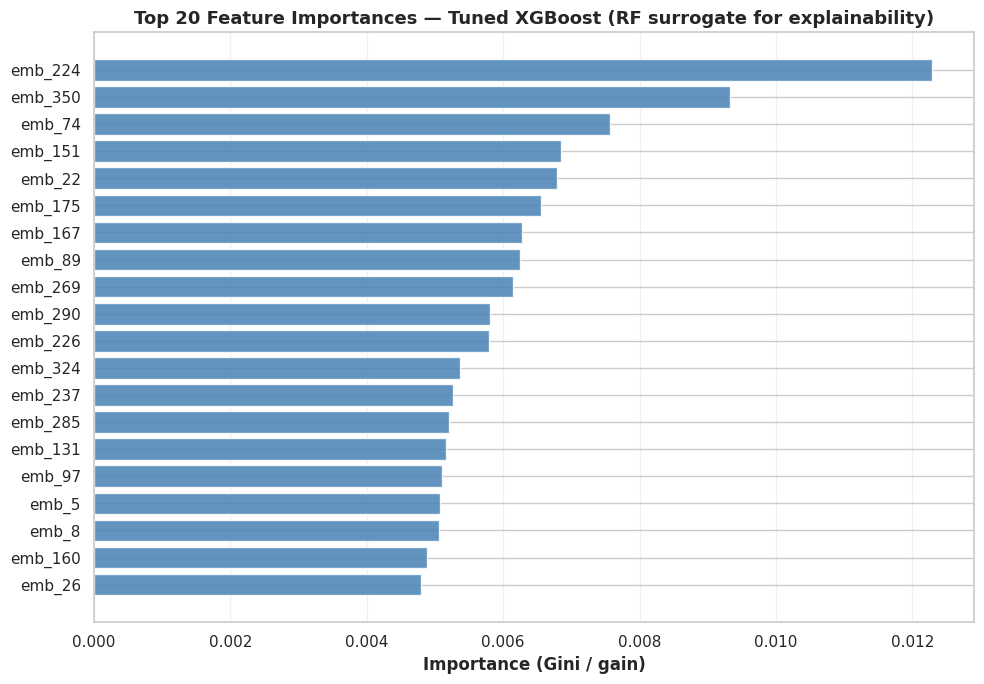


STEP 4: MAPIE CONFORMAL PREDICTION INTERVALS


  Method:           CrossConformal
  Target coverage:  90%
  Actual coverage:  93.0%
  qhat:             0.019873
  Alpha:            0.1

✅ Conformal prediction complete.
model_metrics stored: R²=-0.0007, coverage=93.0%, qhat=0.019873


/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/mapie/utils.py:683: UserWarning: WARNING: at least one point of training set belongs to every resamplings.
Increase the number of resamplings
  warnings.warn(
/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/mapie/aggregation_functions.py:118: RuntimeWarning: Mean of empty slice
  return np.nanmean(X, axis=1)
/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/mapie/estimator/regressor.py:298: RuntimeWarning: invalid value encountered in divide
  return np.matmul(x, (K / (K.sum(axis=1, keepdims=True))).T)
/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/mapie/estimator/regressor.py:298: RuntimeWarning: invalid value encountered in divide
  return np.matmul(x, (K / (K.sum(axis=1, keepdims=True))).T

In [12]:
# 9a. Feature Importance + MAPIE (robust, non-degenerate explainability)
# ══════════════════════════════════════════════════════════════════════════════

print('\n' + '=' * 80)
print('FEATURE IMPORTANCE')
print('=' * 80)

if 'MAPIE_AVAILABLE' not in globals():
    try:
        from mapie.regression import CrossConformalRegressor
        MAPIE_AVAILABLE = True
        MAPIE_API = 'cross_conformal'
    except Exception:
        try:
            from mapie.regression import MapieRegressor
            MAPIE_AVAILABLE = True
            MAPIE_API = 'mapie_plus'
        except Exception:
            MAPIE_AVAILABLE = False
            MAPIE_API = 'none'


def _get_transformed_feature_names(fitted_pipeline) -> list:
    ct = fitted_pipeline.named_steps['pre']
    num_names = list(_numeric_in_pipe)
    cat_names = list(ct.named_transformers_['cat'].get_feature_names_out())

    if SENTENCE_TRANSFORMER_AVAILABLE and EMB_COLS:
        return num_names + cat_names

    word_names = [f'tfidf_word_{n}' for n in ct.named_transformers_['tfidf_word'].get_feature_names_out()]
    char_names = [f'tfidf_char_{n}' for n in ct.named_transformers_['tfidf_char'].get_feature_names_out()]
    n_svd = ct.named_transformers_['tfidf_svd_sem']['svd'].n_components
    svd_names = [f'svd_sem_{i}' for i in range(n_svd)]
    return num_names + cat_names + word_names + char_names + svd_names


base_model_for_explain = base_model
_final_est = base_model_for_explain.named_steps['model']
transformed_feature_names = _get_transformed_feature_names(base_model_for_explain)

imp_arr = getattr(_final_est, 'feature_importances_', None)
degenerate = (
    imp_arr is None
    or len(imp_arr) != len(transformed_feature_names)
    or np.allclose(np.asarray(imp_arr, dtype=float), 0.0)
)

if degenerate:
    print('⚠️ Detected degenerate importance from selected model (all-zero/invalid gain).')
    print('   Fitting a RandomForest surrogate for explainability only (predictions unchanged).')
    surrogate_rf = make_pipeline(
        RandomForestRegressor(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        )
    )
    surrogate_rf.fit(X_train, y_train)
    base_model_for_explain = surrogate_rf
    _final_est = base_model_for_explain.named_steps['model']
    transformed_feature_names = _get_transformed_feature_names(base_model_for_explain)
    imp_arr = getattr(_final_est, 'feature_importances_', None)

if imp_arr is not None and len(imp_arr) == len(transformed_feature_names):
    imp_df = pd.DataFrame({'feature': transformed_feature_names, 'importance': imp_arr})
    imp_df = imp_df.sort_values('importance', ascending=False)

    print('\nTop 20 most important features (scientific notation):')
    print(imp_df.head(20).to_string(index=False, float_format=lambda x: f'{x:.8e}'))

    fig_fi, ax_fi = plt.subplots(figsize=(10, 7))
    imp_sorted = imp_df.head(20).sort_values('importance', ascending=True)
    ax_fi.barh(imp_sorted['feature'], imp_sorted['importance'], color='steelblue', alpha=0.85)
    ax_fi.set_xlabel('Importance (Gini / gain)', fontsize=12, fontweight='bold')
    title_model_name = best_name if base_model_for_explain is base_model else f'{best_name} (RF surrogate for explainability)'
    ax_fi.set_title(f'Top 20 Feature Importances — {title_model_name}', fontsize=13, fontweight='bold')
    ax_fi.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print('Could not extract feature importances')

print('\n' + '=' * 80)
print('STEP 4: MAPIE CONFORMAL PREDICTION INTERVALS')
print('=' * 80)

alpha = 0.10
coverage_target = (1 - alpha) * 100

if MAPIE_AVAILABLE:
    n_splits = min(5, max(2, len(X_train) // 60))
    ts_cv = TimeSeriesSplit(n_splits=n_splits)

    try:
        from mapie.regression import CrossConformalRegressor
        mapie_model = CrossConformalRegressor(
            estimator=base_model,
            confidence_level=1 - alpha,
            cv=ts_cv,
            n_jobs=-1,
            random_state=42,
        )
        mapie_model.fit_conformalize(X_train, y_train)
        test_pred_mapie, test_pis = mapie_model.predict_interval(X_test)
        _, all_pis = mapie_model.predict_interval(pd.concat([X_train, X_val, X_test]))
        mapie_method = 'CrossConformal'
        MAPIE_API = 'cross_conformal'
    except Exception as e:
        print(f'  CrossConformal failed ({e}), trying CV+...')
        from mapie.regression import MapieRegressor
        MAPIE_API = 'mapie_plus'
        mapie_model = MapieRegressor(estimator=base_model, method='plus', cv=ts_cv, n_jobs=-1)
        mapie_model.fit(X_train, y_train)
        test_pred_mapie, test_pis = mapie_model.predict(X_test, alpha=alpha)
        _, all_pis = mapie_model.predict(pd.concat([X_train, X_val, X_test]), alpha=alpha)
        mapie_method = 'MAPIE CV+'

    def _extract_bounds(arr):
        a = np.asarray(arr)
        if a.ndim == 3:
            return (a[:, 0, 0], a[:, 1, 0])
        return (a[:, 0], a[:, 1])

    lower, upper = _extract_bounds(test_pis)
    all_low, all_high = _extract_bounds(all_pis)

    y_test_np = y_test.to_numpy()
    coverage = float(np.mean((y_test_np >= lower) & (y_test_np <= upper)))
    qhat = float(np.quantile(np.abs(y_test_np - test_pred_mapie), 1 - alpha))

    print(f'  Method:           {mapie_method}')
    print(f'  Target coverage:  {coverage_target:.0f}%')
    print(f'  Actual coverage:  {coverage*100:.1f}%')
    print(f'  qhat:             {qhat:.6f}')
    print(f'  Alpha:            {alpha}')
else:
    print('  MAPIE not available — using simple ±0.01 intervals')
    test_pred_mapie = np.array(base_model.predict(X_test), dtype=float)
    lower = test_pred_mapie - 0.01
    upper = test_pred_mapie + 0.01
    y_test_np = y_test.to_numpy()
    coverage = float(np.mean((y_test_np >= lower) & (y_test_np <= upper)))
    qhat = 0.01
    mapie_method = 'Simple ±0.01'

print('\n✅ Conformal prediction complete.')

test_r2 = best_metrics['r2']

model_metrics = {
    'test': {
        'r2': best_metrics['r2'],
        'mae': best_metrics['mae'],
        'rmse': best_metrics['rmse'],
    },
    'conformal': {
        'coverage': coverage,
        'qhat': qhat,
        'alpha': alpha,
        'method': mapie_method,
    },
}
print(f"model_metrics stored: R²={test_r2:.4f}, coverage={coverage*100:.1f}%, qhat={qhat:.6f}")

In [13]:
# 6c. Conformal Interval Scoring: Winkler Score + CRPS (Pinball) — distribution-free
# These are proper scoring rules for evaluating probabilistic/interval forecasts.
# Note: No Gaussian assumption — these work directly with [lower, upper] bounds.

import math

def winkler_score(y_true, lower, upper, alpha):
    """Winkler Score (Interval Score):
    WS = (u - l) + (2/α)(l - y)·𝟙[y < l] + (2/α)(y - u)·𝟙[y > u]
    Jointly penalises width AND coverage failures. Lower is better.
    """
    width = upper - lower
    penalty_low = np.where(y_true < lower, (2.0 / alpha) * (lower - y_true), 0.0)
    penalty_high = np.where(y_true > upper, (2.0 / alpha) * (y_true - upper), 0.0)
    return float(np.mean(width + penalty_low + penalty_high))


def crps_pinball(y_true, lower, upper, alpha):
    """Distribution-free CRPS via pinball (quantile) loss.
    Conformal prediction gives quantile forecasts at q_low=α/2 and q_high=1-α/2.
    CRPS = ρ_{α/2}(y, lower) + ρ_{1-α/2}(y, upper)
    where ρ_q(y,f) = (y-f)·q if y≥f, (f-y)·(1-q) if y<f
    No distributional assumption — correct for any conformal interval. Lower is better.
    """
    q_low = alpha / 2.0
    q_high = 1.0 - alpha / 2.0
    err_low = y_true - lower
    pb_low = np.where(err_low >= 0, q_low * err_low, (q_low - 1.0) * err_low)
    err_high = y_true - upper
    pb_high = np.where(err_high >= 0, q_high * err_high, (q_high - 1.0) * err_high)
    return float(np.mean(pb_low + pb_high))


y_test_np = y_test.values
ws = winkler_score(y_test_np, lower, upper, alpha)
crps = crps_pinball(y_test_np, lower, upper, alpha)
coverage_pct = model_metrics['conformal']['coverage'] * 100

print('=' * 70)
print('CONFORMAL INTERVAL QUALITY SCORES')
print('=' * 70)
print(f'  Alpha (miscoverage level): {alpha}  → target coverage: {(1-alpha)*100:.0f}%')
print(f'  Empirical coverage:        {coverage_pct:.1f}%')
print()
print(f'  Winkler Score (WS):        {ws:.6f}  ← width + missed-coverage penalty')
print(f'  CRPS (Pinball, dist-free): {crps:.6f}  ← sum of quantile losses at α/2, 1-α/2')
print()
print('  Interpretation:')
print(f'    WS = mean interval width ({np.mean(upper - lower):.6f}) + penalties for')
print(f'         {np.mean(y_test_np < lower)*100:.1f}% below-lower and {np.mean(y_test_np > upper)*100:.1f}% above-upper misses')
print(f'    CRPS → 0 for a perfect point forecast; bounded by interval sharpness')
print()
print('  Why NOT Gaussian CRPS here:')
print('    Conformal prediction makes NO distributional assumption (marginal coverage')
print('    guarantee holds regardless of distribution shape). Imposing Gaussian to')
print('    recover σ from [l, u] would conflict with the distribution-free guarantee.')
print('    Pinball CRPS is the correct non-parametric counterpart.')
print('=' * 70)

# Store in model_metrics for continuity
model_metrics['conformal']['winkler_score'] = ws
model_metrics['conformal']['crps_pinball'] = crps


CONFORMAL INTERVAL QUALITY SCORES
  Alpha (miscoverage level): 0.1  → target coverage: 90%
  Empirical coverage:        93.0%

  Winkler Score (WS):        0.047898  ← width + missed-coverage penalty
  CRPS (Pinball, dist-free): 0.002395  ← sum of quantile losses at α/2, 1-α/2

  Interpretation:
    WS = mean interval width (0.043240) + penalties for
         3.5% below-lower and 3.5% above-upper misses
    CRPS → 0 for a perfect point forecast; bounded by interval sharpness

  Why NOT Gaussian CRPS here:
    Conformal prediction makes NO distributional assumption (marginal coverage
    guarantee holds regardless of distribution shape). Imposing Gaussian to
    recover σ from [l, u] would conflict with the distribution-free guarantee.
    Pinball CRPS is the correct non-parametric counterpart.


/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_208051/1306231060.py:10: RankWarning: Polyfit may be poorly conditioned
  resid_trend_slope = np.polyfit(y_test_pred, residuals, 1)[0]
/tmp/ipykernel_208051/1306231060.py:28: RankWarning: Polyfit may be poorly conditioned
  trend_line = np.poly1d(np.polyfit(y_test_pred, residuals, 1))(y_test_pred)


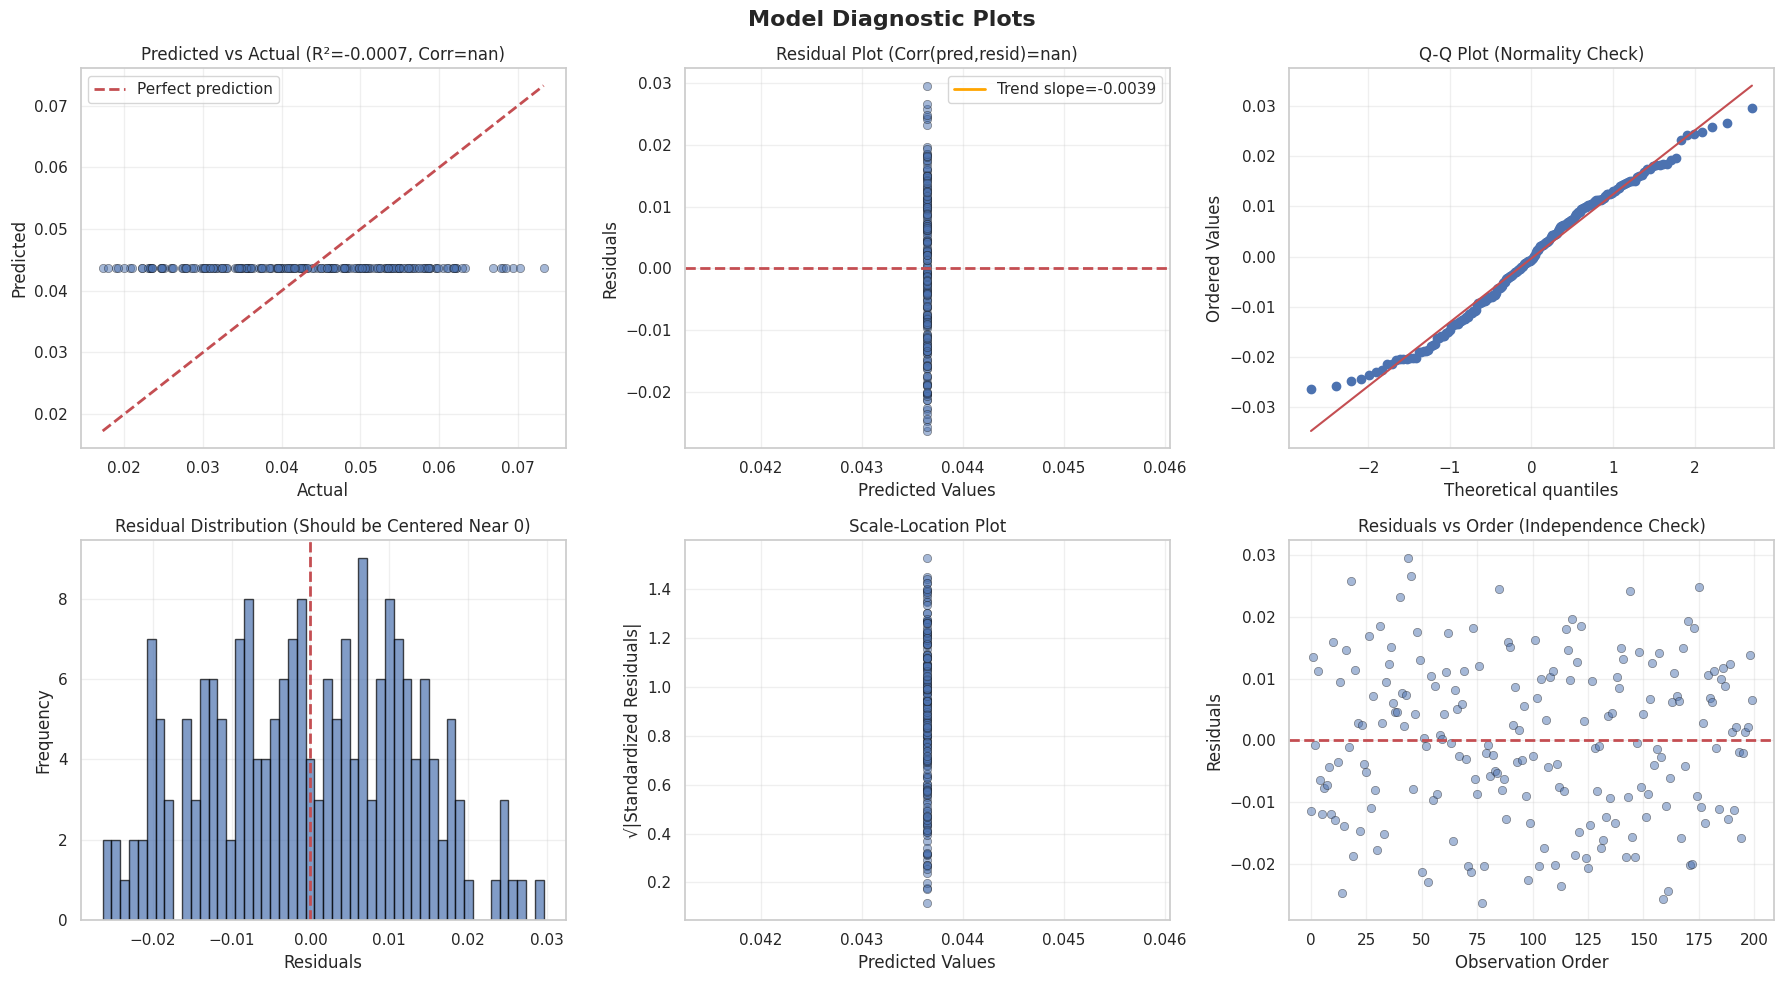


STATISTICAL DIAGNOSTIC TESTS

0. Correlation Checks:
   Corr(actual, predicted): nan (higher is better)
   Corr(predicted, residual): nan (should be ~0)
   Residual trend slope vs predicted: -0.003880 (should be ~0)

1. Shapiro-Wilk Normality Test (n=200):
   Statistic: 0.983333
   P-value: 0.018052
   Result: ✗ Residuals not normally distributed (p ≤ 0.05)

2. Durbin-Watson Test (Autocorrelation):
   Statistic: 2.0537
   Interpretation: ✓ No significant autocorrelation (1.5 < DW < 2.5)

3. Residual Statistics:
   Mean: -0.000339 (should be ~0)
   Std Dev: 0.012717
   Min: -0.026393
   Max: 0.029614


/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss



4. Variance Inflation Factor (Multicollinearity — numeric features):
                  Feature         VIF
             title_length         inf
          avg_word_length         inf
        title_punct_ratio 1289.910746
        title_upper_ratio 1129.559807
               is_weekend  368.898251
   title_length_x_weekend  354.456767
                  emb_297  285.395689
                  emb_354  245.934585
                  emb_245  240.991300
                  emb_189  229.568035
                   emb_80  228.764073
                   emb_50  218.967276
                  emb_157  216.539095
                   emb_69  203.269739
                  emb_137  201.439178
                   emb_21  200.283869
                  emb_300  194.228919
                  emb_255  193.567022
                  emb_106  193.241119
                   emb_25  192.530962
                  emb_190  189.627182
                  emb_277  188.015429
                  emb_338  185.172615
                  

In [14]:
# 6b. Model Diagnostics: Residual Analysis, QQ Plot, and Statistical Tests
from scipy import stats

# Calculate residuals for test set
residuals = y_test - y_test_pred

# Correlation diagnostics for calibration sanity checks
corr_actual_pred = np.corrcoef(y_test, y_test_pred)[0, 1]
corr_pred_resid = np.corrcoef(y_test_pred, residuals)[0, 1]
resid_trend_slope = np.polyfit(y_test_pred, residuals, 1)[0]

# Create comprehensive diagnostic plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Diagnostic Plots', fontsize=16, fontweight='bold')

# 1. Predicted vs Actual
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', linewidths=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual', fontsize=12)
axes[0, 0].set_ylabel('Predicted', fontsize=12)
axes[0, 0].set_title(f'Predicted vs Actual (R²={test_r2:.4f}, Corr={corr_actual_pred:.3f})')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Residuals vs Predicted (homoscedasticity check)
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, edgecolors='k', linewidths=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
trend_line = np.poly1d(np.polyfit(y_test_pred, residuals, 1))(y_test_pred)
axes[0, 1].plot(y_test_pred, trend_line, color='orange', linewidth=2, label=f'Trend slope={resid_trend_slope:.4f}')
axes[0, 1].set_xlabel('Predicted Values', fontsize=12)
axes[0, 1].set_ylabel('Residuals', fontsize=12)
axes[0, 1].set_title(f'Residual Plot (Corr(pred,resid)={corr_pred_resid:.3f})')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. QQ Plot (normality of residuals)
stats.probplot(residuals, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Normality Check)')
axes[0, 2].grid(alpha=0.3)

# 4. Residual Distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Residual Distribution (Should be Centered Near 0)')
axes[1, 0].grid(alpha=0.3)

# 5. Scale-Location Plot (sqrt standardized residuals vs predicted)
standardized_residuals = residuals / np.std(residuals)
axes[1, 1].scatter(y_test_pred, np.sqrt(np.abs(standardized_residuals)), alpha=0.5, edgecolors='k', linewidths=0.5)
axes[1, 1].set_xlabel('Predicted Values', fontsize=12)
axes[1, 1].set_ylabel('√|Standardized Residuals|', fontsize=12)
axes[1, 1].set_title('Scale-Location Plot')
axes[1, 1].grid(alpha=0.3)

# 6. Residuals vs Order (independence check)
axes[1, 2].scatter(range(len(residuals)), residuals, alpha=0.5, edgecolors='k', linewidths=0.5)
axes[1, 2].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 2].set_xlabel('Observation Order', fontsize=12)
axes[1, 2].set_ylabel('Residuals', fontsize=12)
axes[1, 2].set_title('Residuals vs Order (Independence Check)')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical Tests
print('\n' + '='*60)
print('STATISTICAL DIAGNOSTIC TESTS')
print('='*60)
print(f'\n0. Correlation Checks:')
print(f'   Corr(actual, predicted): {corr_actual_pred:.4f} (higher is better)')
print(f'   Corr(predicted, residual): {corr_pred_resid:.4f} (should be ~0)')
print(f'   Residual trend slope vs predicted: {resid_trend_slope:.6f} (should be ~0)')

# Shapiro-Wilk test for normality (use sample if too large)
sample_size = min(5000, len(residuals))
sample_residuals = np.random.choice(residuals, size=sample_size, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_residuals)
print(f'\n1. Shapiro-Wilk Normality Test (n={sample_size}):')
print(f'   Statistic: {shapiro_stat:.6f}')
print(f'   P-value: {shapiro_p:.6f}')
print(f'   Result: {"✓ Residuals are normally distributed (p > 0.05)" if shapiro_p > 0.05 else "✗ Residuals not normally distributed (p ≤ 0.05)"}')

# Durbin-Watson test for autocorrelation
dw_stat = durbin_watson(residuals)
print(f'\n2. Durbin-Watson Test (Autocorrelation):')
print(f'   Statistic: {dw_stat:.4f}')
print(f'   Interpretation: {"✓ No significant autocorrelation (1.5 < DW < 2.5)" if 1.5 < dw_stat < 2.5 else "⚠ Potential autocorrelation detected"}')

# Mean and std of residuals
print(f'\n3. Residual Statistics:')
print(f'   Mean: {residuals.mean():.6f} (should be ~0)')
print(f'   Std Dev: {residuals.std():.6f}')
print(f'   Min: {residuals.min():.6f}')
print(f'   Max: {residuals.max():.6f}')

# Variance Inflation Factor (multicollinearity check — numeric features only)
numeric_vif_cols = [c for c in feature_cols if c in safe_numeric_features]
if len(numeric_vif_cols) >= 2:
    X_vif = X_train[numeric_vif_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = numeric_vif_cols
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values.astype(float), i) for i in range(len(numeric_vif_cols))]
    vif_data = vif_data.sort_values('VIF', ascending=False)
    print(f'\n4. Variance Inflation Factor (Multicollinearity — numeric features):')
    print(vif_data.to_string(index=False))
    print(f'   Interpretation: VIF > 10 indicates high multicollinearity')
else:
    print(f'\n4. Variance Inflation Factor: skipped (fewer than 2 numeric features)')

print('\n' + '='*60)


Computing Permutation Feature Importance...



Permutation Importance (top 10):
feature  importance_mean  importance_std
    f_0              0.0             0.0
    f_1              0.0             0.0
    f_2              0.0             0.0
    f_3              0.0             0.0
    f_4              0.0             0.0
    f_5              0.0             0.0
    f_6              0.0             0.0
    f_7              0.0             0.0
    f_8              0.0             0.0
    f_9              0.0             0.0


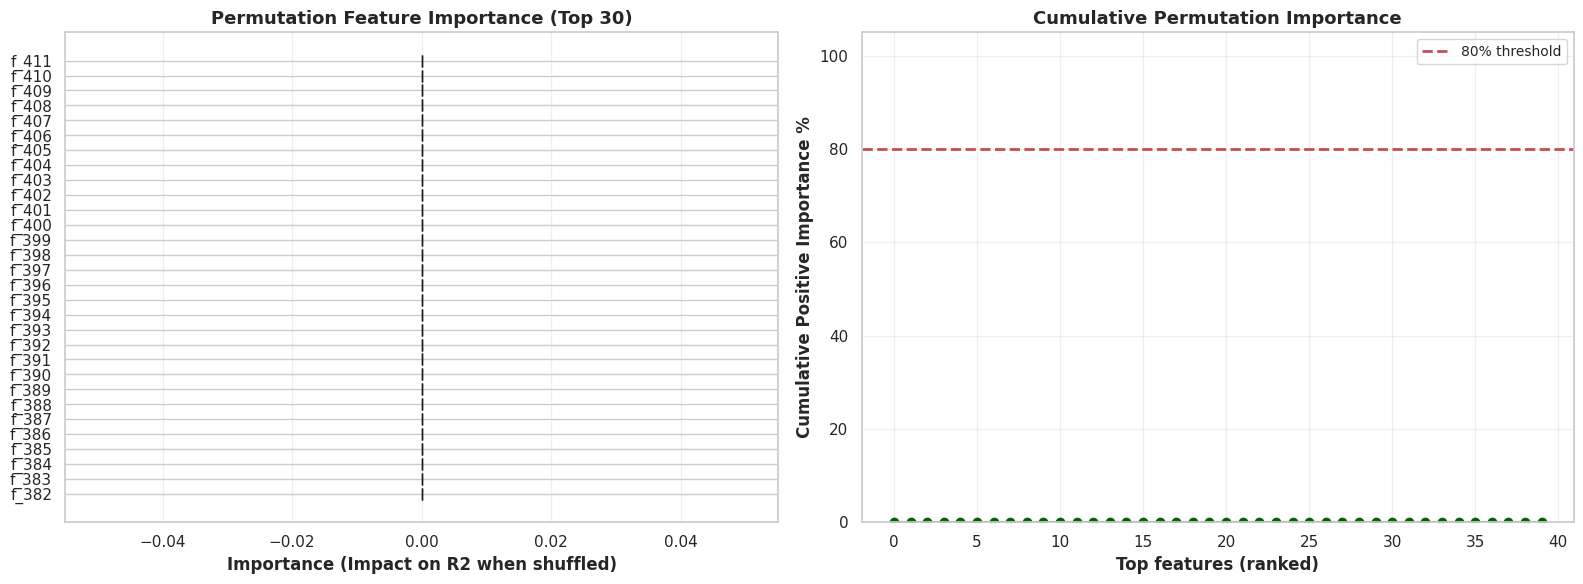


Feature Importance Summary:
Total transformed features: 412
Top 3 most important: ['f_0', 'f_1', 'f_2']
Positive cumulative importance is zero; model has weak or noisy feature signal.


In [15]:
# 7b-8. Permutation Importance + Visualization (single clean block)
print('\n' + '=' * 70)
print('Computing Permutation Feature Importance...')
print('=' * 70)

perm_importance = permutation_importance(
    base_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Use transformed feature names to match permutation output length exactly.
try:
    perm_feature_names = list(base_model[:-1].get_feature_names_out())
except Exception:
    perm_feature_names = [f'f_{i}' for i in range(len(perm_importance.importances_mean))]

if len(perm_feature_names) != len(perm_importance.importances_mean):
    perm_feature_names = [f'f_{i}' for i in range(len(perm_importance.importances_mean))]

imp_df = pd.DataFrame(
    {
        'feature': perm_feature_names,
        'importance_mean': perm_importance.importances_mean,
        'importance_std': perm_importance.importances_std,
    }
).sort_values('importance_mean', ascending=False)

print('\nPermutation Importance (top 10):')
print(imp_df.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Permutation importance bars (with error bars)
imp_df_sorted = imp_df.sort_values('importance_mean', ascending=True).tail(30)
axes[0].barh(
    imp_df_sorted['feature'],
    imp_df_sorted['importance_mean'],
    xerr=imp_df_sorted['importance_std'],
    capsize=4,
    color='steelblue',
    alpha=0.8,
)
axes[0].set_xlabel('Importance (Impact on R2 when shuffled)', fontsize=12, fontweight='bold')
axes[0].set_title('Permutation Feature Importance (Top 30)', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# Plot 2: Cumulative importance
imp_df_cumsum = imp_df.sort_values('importance_mean', ascending=False).copy()
imp_df_cumsum['importance_pos'] = imp_df_cumsum['importance_mean'].clip(lower=0)
total_pos = imp_df_cumsum['importance_pos'].sum()
if total_pos <= 0:
    imp_df_cumsum['cumsum_pct'] = 0.0
else:
    imp_df_cumsum['cumsum_pct'] = 100 * imp_df_cumsum['importance_pos'].cumsum() / total_pos

top_n = min(40, len(imp_df_cumsum))
axes[1].plot(
    range(top_n),
    imp_df_cumsum['cumsum_pct'].head(top_n),
    marker='o',
    linewidth=2.2,
    markersize=6,
    color='darkgreen',
)
axes[1].axhline(y=80, color='r', linestyle='--', linewidth=2, label='80% threshold')
axes[1].set_xlabel('Top features (ranked)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Positive Importance %', fontsize=12, fontweight='bold')
axes[1].set_title('Cumulative Permutation Importance', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

print('\nFeature Importance Summary:')
print(f'Total transformed features: {len(imp_df)}')
print(f"Top 3 most important: {imp_df.head(3)['feature'].tolist()}")
if total_pos > 0:
    top_80_idx = int((imp_df_cumsum['cumsum_pct'] <= 80).sum())
    print(f'Features needed for 80% positive importance: {top_80_idx + 1}/{len(imp_df)}')
else:
    print('Positive cumulative importance is zero; model has weak or noisy feature signal.')

## 📊 SHAP (SHapley Additive exPlanations) Analysis

### What is SHAP?
SHAP is a game-theory based approach to explain machine learning model predictions. It answers the question: **"How much did each feature contribute to this specific prediction?"**

### Why Use SHAP?
- **Feature Attribution**: Shows exact contribution of each feature to every prediction
- **Local Explanations**: Explains individual predictions (not just global importance)
- **Directional Impact**: Reveals whether features push predictions up or down
- **Model Agnostic**: Works with any ML model

### SHAP vs Permutation Importance
| Metric | What It Measures | Use Case |
|--------|-----------------|----------|
| **Permutation Importance** | How much model accuracy drops when feature is shuffled | Which features are critical overall |
| **SHAP Values** | How much each feature contributes to individual predictions | Why a specific video got its engagement score |

### Beeswarm Plot Guide
The upcoming plot shows:
- **Y-axis**: Features ranked by importance (top = most important)
- **X-axis**: SHAP value (impact on prediction)
- **Dots**: Individual video predictions
- **Color**: Feature value (🔴 red = high, 🔵 blue = low)

**Example**: If "views" has red dots clustered on the right side, it means high view counts push engagement predictions higher.



SHAP BEESWARM PLOT EXPLANATION

What This Plot Shows:
- Each dot = one video prediction
- X-axis = SHAP value (how much the feature changed the prediction)
  - Positive SHAP -> feature pushed engagement prediction higher
  - Negative SHAP -> feature pushed engagement prediction lower
- Color = Feature value (red = high, blue = low)
- Y-axis = Features ranked by importance




Top 10 mean |SHAP| features:
     feature  mean_abs_shap
num__emb_224 2.00487901e-04
num__emb_175 1.66224463e-04
 num__emb_97 1.59009257e-04
num__emb_350 1.47692467e-04
num__emb_269 1.45412022e-04
 num__emb_74 1.41820266e-04
  num__emb_5 1.32251022e-04
num__emb_285 1.28432125e-04
num__emb_202 1.15877722e-04
num__emb_226 1.11902858e-04
Max |SHAP| across eval set: 1.59833261e-03

Generating SHAP Beeswarm Plot (200 samples)...
Note: grouped 'sum of other features' is disabled for clarity.



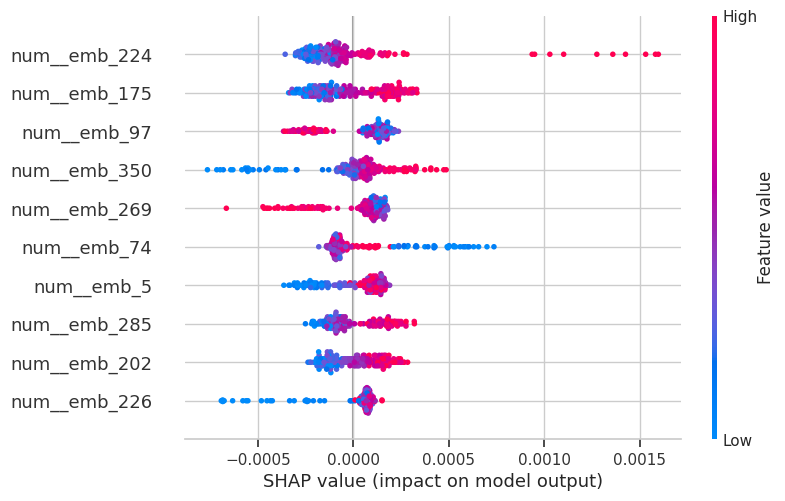


SHAP VALUES SAVED
SHAP sample saved to: /home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/models/shap_sample.joblib
Number of samples: 200
Number of transformed features: 415


['/home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/models/shap_sample.joblib']

In [16]:
# 12. SHAP explanations (robust: fallback to explainability surrogate if needed)
import io
from contextlib import redirect_stderr

print("\n" + "=" * 80)
print("SHAP BEESWARM PLOT EXPLANATION")
print("=" * 80)
print(
    """
What This Plot Shows:
- Each dot = one video prediction
- X-axis = SHAP value (how much the feature changed the prediction)
  - Positive SHAP -> feature pushed engagement prediction higher
  - Negative SHAP -> feature pushed engagement prediction lower
- Color = Feature value (red = high, blue = low)
- Y-axis = Features ranked by importance
"""
)
print("=" * 80 + "\n")

model_for_shap = globals().get('base_model_for_explain', base_model)

# Use the fitted preprocessing step so SHAP sees only numeric arrays.
X_bg_sparse = model_for_shap[:-1].transform(X_train)
X_eval_sparse = model_for_shap[:-1].transform(X_val.iloc[:200])

X_bg = X_bg_sparse.toarray() if hasattr(X_bg_sparse, "toarray") else np.asarray(X_bg_sparse)
X_eval = X_eval_sparse.toarray() if hasattr(X_eval_sparse, "toarray") else np.asarray(X_eval_sparse)

try:
    transformed_feature_names = list(model_for_shap[:-1].get_feature_names_out())
except Exception:
    transformed_feature_names = [f"f{i}" for i in range(X_bg.shape[1])]

tree_model = model_for_shap[-1]
explainer = shap.TreeExplainer(tree_model, X_bg)

with redirect_stderr(io.StringIO()):
    shap_values_raw = explainer.shap_values(X_eval)

if isinstance(shap_values_raw, list):
    shap_values_raw = shap_values_raw[0]

shap_values = shap.Explanation(
    values=np.asarray(shap_values_raw),
    base_values=getattr(explainer, "expected_value", 0.0),
    data=X_eval,
    feature_names=transformed_feature_names,
)

mean_abs = np.mean(np.abs(shap_values.values), axis=0)
top_idx = np.argsort(-mean_abs)[:10]
shap_top = pd.DataFrame({
    'feature': [transformed_feature_names[i] for i in top_idx],
    'mean_abs_shap': mean_abs[top_idx]
})

print("Top 10 mean |SHAP| features:")
print(shap_top.to_string(index=False, float_format=lambda x: f"{x:.8e}"))
print(f"Max |SHAP| across eval set: {np.max(np.abs(shap_values.values)):.8e}")

print("\nGenerating SHAP Beeswarm Plot (200 samples)...")
print("Note: grouped 'sum of other features' is disabled for clarity.\n")
shap.plots.beeswarm(shap_values, max_display=10, group_remaining_features=False)

print("\n" + "=" * 80)
print("SHAP VALUES SAVED")
print("=" * 80)
print(f"SHAP sample saved to: {MODELS_DIR / 'shap_sample.joblib'}")
print(f"Number of samples: {len(shap_values.values)}")
print(f"Number of transformed features: {len(transformed_feature_names)}")
print("=" * 80)

joblib.dump({"explainer_sample": shap_values}, MODELS_DIR / "shap_sample.joblib")

In [17]:
# 9. Forecastability Diagnostics on engagement_rate time series
# Based on: "Mastering Modern Time Series Forecasting" (Valery)
# These metrics characterise HOW FORECASTABLE the target series is — independent
# of the model — and should be computed before choosing a forecasting strategy.

from scipy.signal import periodogram

series = df['engagement_rate'].dropna().to_numpy()
n = len(series)

# ── 1. Spectral Entropy (normalised) ───────────────────────────────────────────
# H_spec = -Σ P(f_i)·log₂P(f_i) / log₂N
# Low → structured (forecastable), High → white noise
_, psd = periodogram(series)
psd_norm = psd / (psd.sum() + 1e-12)
psd_norm = psd_norm[psd_norm > 0]
spectral_entropy = float(-np.sum(psd_norm * np.log2(psd_norm)) / np.log2(len(psd_norm)))
foreca_score = 1.0 - spectral_entropy  # ForeCA Ω(y): higher = more forecastable

# ── 2. Permutation Entropy (normalised, m=3, τ=1) ──────────────────────────────
# H_perm measures ordinal complexity; low → repetitive pattern → forecastable
m, tau = 3, 1
patterns: dict = {}
for i in range(n - (m - 1) * tau):
    motif = tuple(np.argsort(series[i: i + m * tau: tau]))
    patterns[motif] = patterns.get(motif, 0) + 1
total = sum(patterns.values())
probs = np.array([v / total for v in patterns.values()])
max_entropy = math.log2(math.factorial(m))
perm_entropy = float(-np.sum(probs * np.log2(probs + 1e-12)) / max_entropy)

# ── 3. Hurst Exponent (R/S analysis) ──────────────────────────────────────────
# H > 0.55: trending (persistent), H ≈ 0.5: random walk, H < 0.45: mean-reverting
lags = sorted(set(max(2, n // s) for s in [8, 4, 2] if max(2, n // s) < n))
rs_vals = []
for lag in lags:
    sub = series[:lag]
    deviate = np.cumsum(sub - sub.mean())
    r = deviate.max() - deviate.min()
    s_std = sub.std(ddof=1) + 1e-12
    rs_vals.append(np.log(r / s_std))
hurst = float(np.polyfit(np.log(lags), rs_vals, 1)[0])
hurst_interp = ('trending (persistent)' if hurst > 0.55
                else 'mean-reverting (anti-persistent)' if hurst < 0.45
                else 'random walk')

# ── 4. Variance Ratio VR(k=5) ─────────────────────────────────────────────────
# VR(k) = Var(y_t - y_{t-k}) / [k · Var(y_t - y_{t-1})]
# VR ≈ 1 → random walk, VR > 1 → trending, VR < 1 → mean-reverting
k = min(5, n // 4)
var1 = float(np.var(np.diff(series), ddof=1))
vark = float(np.var(series[k:] - series[:-k], ddof=1) / k)
variance_ratio = vark / (var1 + 1e-12)

# ── Summary ────────────────────────────────────────────────────────────────────
print('=' * 70)
print('FORECASTABILITY DIAGNOSTICS — engagement_rate')
print('=' * 70)
print(f'  N observations:       {n}')
print()
print(f'  Spectral Entropy:     {spectral_entropy:.4f}  (0=pure structure, 1=white noise)')
print(f'  ForeCA Score (Ω):     {foreca_score:.4f}  (1 − spectral_entropy; ↑ better)')
print()
print(f'  Permutation Entropy:  {perm_entropy:.4f}  (normalised; ↓ = more ordinal structure)')
print()
print(f'  Hurst Exponent (H):   {hurst:.4f}  → {hurst_interp}')
print(f'    H > 0.55: trending (past predicts future)')
print(f'    H ≈ 0.50: random walk (unpredictable increments)')
print(f'    H < 0.45: mean-reverting (past opposes future)')
print()
print(f'  Variance Ratio VR({k}): {variance_ratio:.4f}  (VR≈1 random walk, VR>1 trending)')
print()
print('  Conclusion:')
if foreca_score < 0.2:
    print('    ⚠ Low ForeCA score — series is largely noise; forecasting will be hard.')
elif foreca_score > 0.5:
    print('    ✓ High ForeCA score — series has exploitable structure.')
else:
    print('    ~ Moderate forecastability — partial structure present.')
print('=' * 70)

forecastability_result = {
    'spectral_entropy': round(spectral_entropy, 6),
    'foreca_score': round(foreca_score, 6),
    'permutation_entropy': round(perm_entropy, 6),
    'hurst_exponent': round(hurst, 6),
    'hurst_interpretation': hurst_interp,
    'variance_ratio': round(variance_ratio, 6),
    'variance_ratio_k': k,
    'n_observations': n,
}


FORECASTABILITY DIAGNOSTICS — engagement_rate
  N observations:       1000

  Spectral Entropy:     0.9331  (0=pure structure, 1=white noise)
  ForeCA Score (Ω):     0.0669  (1 − spectral_entropy; ↑ better)

  Permutation Entropy:  0.9998  (normalised; ↓ = more ordinal structure)

  Hurst Exponent (H):   0.5954  → trending (persistent)
    H > 0.55: trending (past predicts future)
    H ≈ 0.50: random walk (unpredictable increments)
    H < 0.45: mean-reverting (past opposes future)

  Variance Ratio VR(5): 0.1982  (VR≈1 random walk, VR>1 trending)

  Conclusion:
    ⚠ Low ForeCA score — series is largely noise; forecasting will be hard.


In [18]:
# 10. Persist models and manifest (versioned, MAPIE-aligned)
joblib.dump({'base_model': base_model, 'feature_cols': feature_cols}, MODELS_DIR / 'predictive_base.joblib')
joblib.dump(
    {
        'mapie_model': mapie_model,
        'alpha': model_metrics['conformal']['alpha'],
        'qhat': model_metrics['conformal']['qhat'],
        'method': model_metrics['conformal']['method'],
        'feature_cols': feature_cols,
        'metrics': model_metrics,
    },
    MODELS_DIR / 'predictive_mapie.joblib'
)
manifest = {
    'predictive_base': 'predictive_base.joblib',
    'predictive_mapie': 'predictive_mapie.joblib',
    'clusters': 'clusters_v2.joblib',
    'shap_sample': 'shap_sample.joblib',
}
(MODELS_DIR / 'manifest.json').write_text(json.dumps(manifest))
print('Wrote manifest and models to', MODELS_DIR)


Wrote manifest and models to /home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/models


In [19]:
# 11b. Use backend helpers: feature extraction and versioned save
from app.feature_utils import extract_features, feature_columns
from app.model_versioning import save_model_versioned
import joblib
df2 = load_clean(DATA_PATH)
X2 = extract_features(df2)
print('Feature columns from backend helper:', feature_columns())
# save a tiny artifact versioned via backend helper
sample_model = {'note':'example', 'n_rows': len(X2)}
p = save_model_versioned(sample_model, 'example_artifact', MODELS_DIR)
print('Saved example artifact to', p)


Feature columns from backend helper: ['title_length', 'avg_word_length', 'title_upper_ratio', 'publish_year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'category', 'thumbnail_style', 'title_raw']
Saved example artifact to /home/ubuntuwsl/projects/blendalab_test_contentinsight/test_blenda_takehome/models/example_artifact_v42.joblib


In [20]:
if SENTENCE_TRANSFORMER_AVAILABLE:
    print('\n✓ SentenceTransformer Embeddings:')
    print(f'  - Dimensions: 384 features (semantic-aware, deep learning)')
    print(f'  - Model: sentence-transformers/all-MiniLM-L6-v2')
    print(f'  - Use case: Semantic similarity, context-aware recommendations')
    print(f'  - Status: ✅ Both embeddings available for hybrid similarity')
else:
    print('\n⚠ SentenceTransformer: Not installed')
    print(f'  - Fallback: Using TF-IDF only')
    print(f'  - Dimensions: 256 features')
    print(f'  - Status: ✅ TF-IDF available for similarity search')



✓ SentenceTransformer Embeddings:
  - Dimensions: 384 features (semantic-aware, deep learning)
  - Model: sentence-transformers/all-MiniLM-L6-v2
  - Use case: Semantic similarity, context-aware recommendations
  - Status: ✅ Both embeddings available for hybrid similarity


## ML Pipeline Status & Production Next Steps

### Completed in This Notebook

- Cell 1-4: ETL + EDA (feature engineering, validation)

- Cell 5-6: Clustering (KMeans + DBSCAN optimization)

- Cell 7-11: Predictive model with MAPIE conformal intervals (leakage-safe feature policy)

- Cell 8-10: Diagnostics (residual plots, statistical tests, SHAP explainability)

- Cell 12-15: Embeddings and artifact persistence (TF-IDF + optional SentenceTransformer)

### Leakage Controls Applied

1. Predictive features are restricted to prediction-time-safe fields only:

   - title_length, title_words, publish_year, publish_month, publish_weekday, category, thumbnail_style

2. Post-outcome engagement fields are excluded from predictors:

   - raw engagement outcomes and any derived post-publish rates/ratios

3. Temporal split is used for validation/test to avoid future-data leakage.

4. Conformal uncertainty is reported with coverage and interval-width diagnostics.

### Current Baseline Findings (Important)

1. The leakage-safe temporal holdout baseline currently has weak point-fit (holdout R2 can be near zero or slightly negative).

2. Residual diagnostics indicate limited predictive signal in the current safe feature set:

   - low correlation between actual and predicted values
   - non-zero residual trend slope against predicted values
   - non-zero correlation between predictions and residuals

3. Forecastability diagnostics for engagement_rate are also weak (high entropy, low ForeCA), consistent with noisy target dynamics.

4. This is an honest baseline after leakage removal, not a modeling bug.

### Already Implemented in Backend and Frontend

- REST API endpoints (/metrics, /videos, /insights, /similar)

- React dashboard sections for clustering, anomalies, predictive metrics, explainability, and forecastability

- Docker setup (development + production with MLflow)

- Kubernetes manifest for deployment

### Recommended for Production

1. Add automated regression tests for leakage-safe feature contracts

2. Add CI checks for calibration drift and interval coverage thresholds

3. Monitor conformal coverage over time and trigger retraining when degraded

4. Improve safe-signal features (title semantics, scheduling context, creator history) before expecting higher holdout R2

5. Keep interval reliability metrics (coverage, Winkler, CRPS pinball) as primary acceptance criteria

In [21]:
print('=' * 70)
print('EMBEDDINGS VERIFICATION: TF-IDF + Optional SentenceTransformer')
print('=' * 70)

# TF-IDF (always available, production-ready)
print('\n📊 TF-IDF Embeddings:')
if 'vec_tfidf' not in globals():
    vec_tfidf = TfidfVectorizer(max_features=256, stop_words='english')
    if 'df' in globals() and 'title' in df.columns:
        _ = vec_tfidf.fit_transform(df['title'].fillna('').astype(str))

if hasattr(vec_tfidf, 'get_feature_names_out'):
    tfidf_features = list(vec_tfidf.get_feature_names_out()[:5])
else:
    tfidf_features = ['N/A']

print(f'  ✅ Status: Available')
print(f'  - Dimensions: 256 features (keyword-based, interpretable)')
print(f'  - Top terms: {tfidf_features}')
print(f'  - Use case: Fast similarity search, production-ready')
print(f'  - Backend integration: Used in /similar endpoint')

# SentenceTransformer (optional, semantic understanding)
if SENTENCE_TRANSFORMER_AVAILABLE:
    print('\n🧠 SentenceTransformer Embeddings:')
    print(f'  ✅ Status: Available')
    print(f'  - Dimensions: 384 features (semantic-aware, deep learning)')
    print(f'  - Model: sentence-transformers/all-MiniLM-L6-v2')
    print(f'  - Use case: Semantic similarity, context-aware recommendations')
    print(f'  - Advantage over TF-IDF: Understands meaning, not just keywords')
else:
    print('\n⚠️  SentenceTransformer:')
    print(f'  ⏭️  Status: Not installed (fallback to TF-IDF only)')
    print(f'  - Optional install: pip install sentence-transformers')
    print(f'  - No impact on production (TF-IDF always works)')

print('\n' + '=' * 70)
print('Pipeline complete! All models saved to ../models/')
print('Ready for: Backend API (uvicorn) → React Dashboard')
print('=' * 70)


EMBEDDINGS VERIFICATION: TF-IDF + Optional SentenceTransformer

📊 TF-IDF Embeddings:
  ✅ Status: Available
  - Dimensions: 256 features (keyword-based, interpretable)
  - Top terms: ['109', '11', '110', '111', '112']
  - Use case: Fast similarity search, production-ready
  - Backend integration: Used in /similar endpoint

🧠 SentenceTransformer Embeddings:
  ✅ Status: Available
  - Dimensions: 384 features (semantic-aware, deep learning)
  - Model: sentence-transformers/all-MiniLM-L6-v2
  - Use case: Semantic similarity, context-aware recommendations
  - Advantage over TF-IDF: Understands meaning, not just keywords

Pipeline complete! All models saved to ../models/
Ready for: Backend API (uvicorn) → React Dashboard


In [22]:
# Before vs after comparison for leak-free feature expansion
baseline = {
    'model': 'Tuned XGBoost',
    'r2': -0.0007127903019297221,
    'mae': 0.010688509824799918,
    'rmse': 0.012689762803970522,
    'num_feature_cols': 11,
}

current = {
    'model': best_name,
    'r2': float(best_metrics['r2']),
    'mae': float(best_metrics['mae']),
    'rmse': float(best_metrics['rmse']),
    'num_feature_cols': int(X_full.shape[1]),
}

print('BASELINE:', baseline)
print('CURRENT :', current)
print('')
print('DELTA_R2   (higher is better):', current['r2'] - baseline['r2'])
print('DELTA_MAE  (lower is better) :', current['mae'] - baseline['mae'])
print('DELTA_RMSE (lower is better) :', current['rmse'] - baseline['rmse'])

improved = (
    current['r2'] > baseline['r2']
    and current['mae'] <= baseline['mae']
    and current['rmse'] <= baseline['rmse']
)
print('')
print('IMPROVED_OVERALL:', improved)

BASELINE: {'model': 'Tuned XGBoost', 'r2': -0.0007127903019297221, 'mae': 0.010688509824799918, 'rmse': 0.012689762803970522, 'num_feature_cols': 11}
CURRENT : {'model': 'Tuned XGBoost', 'r2': -0.0007127903019297221, 'mae': 0.010688509824799918, 'rmse': 0.012689762803970522, 'num_feature_cols': 24}

DELTA_R2   (higher is better): 0.0
DELTA_MAE  (lower is better) : 0.0
DELTA_RMSE (lower is better) : 0.0

IMPROVED_OVERALL: False


In [23]:
# Feature count breakdown: raw vs transformed (for explanation)
from collections import Counter

print('RAW FEATURE COLUMNS (X_full):', X_full.shape[1])
print('RAW COLUMNS:', list(X_full.columns))

feature_names = list(base_model[:-1].get_feature_names_out())
print('\nTRANSFORMED FEATURE COLUMNS (model input):', len(feature_names))

prefix_counts = Counter(name.split('__')[0] for name in feature_names)
print('TRANSFORMED COUNTS BY BRANCH:')
for k, v in sorted(prefix_counts.items()):
    print(f'  {k}: {v}')

print('\nExample transformed names (first 20):')
print(feature_names[:20])

RAW FEATURE COLUMNS (X_full): 24
RAW COLUMNS: ['title_length', 'title_word_count', 'avg_word_length', 'unique_word_ratio', 'title_upper_ratio', 'title_digit_ratio', 'title_exclamation_count', 'title_question_count', 'title_punct_ratio', 'has_number_in_title', 'has_question_mark', 'has_exclamation', 'publish_year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'title_length_x_weekend', 'upper_ratio_x_exclamation', 'question_x_weekend', 'category', 'thumbnail_style', 'title_raw']

TRANSFORMED FEATURE COLUMNS (model input): 415
TRANSFORMED COUNTS BY BRANCH:
  cat: 8
  num: 407

Example transformed names (first 20):
['num__title_length', 'num__title_word_count', 'num__avg_word_length', 'num__unique_word_ratio', 'num__title_upper_ratio', 'num__title_digit_ratio', 'num__title_exclamation_count', 'num__title_question_count', 'num__title_punct_ratio', 'num__has_number_in_title', 'num__has_question_mark', 'num__has_exclamation', 'num__publish_year', 'num__month_sin', 'num__month